Cell 1 — Cài môi trường

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
!pip -q install \
  langchain==0.2.16 \
  langchain-core==0.2.38 \
  langchain-community==0.2.16 \
  langchain-google-genai==1.0.8 \
  langchain-text-splitters==0.2.4 \
  langchain-chroma==0.1.4 \
  chromadb==0.5.9 \
  gradio bert-score openpyxl

In [2]:
!pip list | grep -E "langchain|google-generativeai|protobuf|chromadb|numpy|pandas"

chromadb                                 0.5.9
geopandas                                1.1.3
google-generativeai                      0.7.2
langchain                                0.2.16
langchain-chroma                         0.1.4
langchain-community                      0.2.16
langchain-core                           0.2.38
langchain-google-genai                   1.0.8
langchain-protocol                       0.0.15
langchain-text-splitters                 0.2.4
numpy                                    1.26.4
pandas                                   2.2.2
pandas-datareader                        0.10.0
pandas-gbq                               0.30.0
pandas-stubs                             2.2.2.240909
protobuf                                 4.25.9
sklearn-pandas                           2.2.0


Cell 2 — Import

In [3]:
import os
import re
import json
import time
import math
import random
import warnings
from pathlib import Path

import pandas as pd
import gradio as gr

from google.colab import files, drive

from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings

from bert_score import score as bertscore_score

warnings.filterwarnings("ignore")

Cell 3 — Mount Drive và API key

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

if "GEMINI_API_KEY" not in os.environ:
    os.environ["GEMINI_API_KEY"] = input("Enter Gemini API key: ")

# Ensure GOOGLE_API_KEY is set from GEMINI_API_KEY for compatibility
if "GEMINI_API_KEY" in os.environ and "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = os.environ["GEMINI_API_KEY"]




Enter Gemini API key: AQ.Ab8RN6JY6qB3VNLNMXXDz3dRcvX5OU4esPrC829ODazaFC5JnQ


Cell 4 — Upload file nội dung trước

In [5]:
print("Upload CONTENT file first")
uploaded_content = files.upload()

content_name = list(uploaded_content.keys())[0]
content_path = f"/content/{content_name}"

print("Content file:", content_path)

Upload CONTENT file first


Saving 30 nội dung.txt to 30 nội dung.txt
Content file: /content/30 nội dung.txt


Cell 5 — Upload file QA sau

In [6]:
print("Upload QA file second")
uploaded_qa = files.upload()

qa_name = list(uploaded_qa.keys())[0]
qa_path = f"/content/{qa_name}"

print("QA file:", qa_path)

Upload QA file second


Saving bo_cau_hoi_tra_loi_hoagiai_01_2014.txt to bo_cau_hoi_tra_loi_hoagiai_01_2014.txt
QA file: /content/bo_cau_hoi_tra_loi_hoagiai_01_2014.txt


Cell 6 — Hàm làm sạch text

In [7]:
def clean_text(text: str) -> str:
    text = str(text)
    text = text.replace("\xa0", " ")
    text = text.replace("\u200b", " ")
    text = re.sub(r"\r\n?", "\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def normalize_text(s: str) -> str:
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

Cell 7 — Parse file nội dung

In [8]:
def extract_legal_code(text: str) -> str:
    m = re.search(r"\b\d+/\d{4}/[A-Z0-9\-]+\b", text)
    return m.group(0) if m else "unknown"

def extract_article_number(text: str) -> str:
    m = re.search(r"Điều\s*(\d+)", text, flags=re.I)
    return m.group(1) if m else "unknown"

def parse_content_txt(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        text = clean_text(f.read())

    pattern = r"Mục\s+(\d+)\s*\nTiêu đề:\s*(.*?)\nNội dung:\s*(.*?)(?=\nMục\s+\d+\s*\nTiêu đề:|\Z)"
    matches = re.findall(pattern, text, flags=re.S)

    rows = []
    for item_id, title, content in matches:
        title = clean_text(title)
        content = clean_text(content)

        if not title or not content:
            continue

        rows.append({
            "item_id": int(item_id),
            "title": title,
            "content": content,
            "article_number": extract_article_number(title),
            "legal_code": extract_legal_code(title),
        })

    return pd.DataFrame(rows)

content_df = parse_content_txt(content_path)
print("Content rows:", len(content_df))
content_df.head()

Content rows: 30


,item_id,title,content,article_number,legal_code
0,1,Điều 1 01/2014/NQLT/CP-UBTƯMTTQVN,Điều 1 01/2014/NQLT/CP-UBTƯMTTQVN hướng dẫn ph...,1,01/2014/NQLT
1,2,Điều 2 01/2014/NQLT/CP-UBTƯMTTQVN,Điều 2 01/2014/NQLT/CP-UBTƯMTTQVN hướng dẫn ph...,2,01/2014/NQLT
2,3,Điều 3 01/2014/NQLT/CP-UBTƯMTTQVN,Điều 3 01/2014/NQLT/CP-UBTƯMTTQVN hướng dẫn ph...,3,01/2014/NQLT
3,4,Điều 4 01/2014/NQLT/CP-UBTƯMTTQVN,Điều 4 01/2014/NQLT/CP-UBTƯMTTQVN hướng dẫn ph...,4,01/2014/NQLT
4,5,Điều 5 01/2014/NQLT/CP-UBTƯMTTQVN,Điều 5 01/2014/NQLT/CP-UBTƯMTTQVN hướng dẫn ph...,5,01/2014/NQLT


Cell 8 — Parse file QA

In [9]:
def parse_qa_txt(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        text = clean_text(f.read())

    pattern = r"Câu\s*(\d+)\s*:\s*(.*?)\nTrả lời:\s*(.*?)(?=\nCâu\s*\d+\s*:|\Z)"
    matches = re.findall(pattern, text, flags=re.S)

    rows = []
    for qid, question, answer in matches:
        question = clean_text(question)
        answer = clean_text(answer)

        if question and answer:
            rows.append({
                "qa_id": int(qid),
                "question": question,
                "gold_answer": answer
            })

    return pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)

qa_df = parse_qa_txt(qa_path)
print("QA rows:", len(qa_df))
qa_df.head()

QA rows: 30


,qa_id,question,gold_answer
0,1,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...
1,2,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động được thực hiện trên cơ...
2,3,Trong công tác hòa giải ở cơ sở cần phát huy v...,Cần phát huy vai trò nòng cốt của Mặt trận Tổ ...
3,4,Việc phối hợp trong công tác hòa giải ở cơ sở ...,"Việc phối hợp phải thường xuyên, kịp thời, đồn..."
4,5,Ai tham gia đóng góp ý kiến về dự thảo văn bản...,Ủy ban Trung ương Mặt trận Tổ quốc Việt Nam và...


Cell 9 — Giới hạn size an toàn cho free API

In [10]:
MAX_CONTENT_DOCS = min(30, len(content_df))
MAX_QA_DOCS = min(30, len(qa_df))

content_df_small = content_df.head(MAX_CONTENT_DOCS).copy().reset_index(drop=True)
qa_df_small = qa_df.head(MAX_QA_DOCS).copy().reset_index(drop=True)

print("Content docs used:", len(content_df_small))
print("QA docs used:", len(qa_df_small))

Content docs used: 30
QA docs used: 30


Cell 10 — Tạo documents cho content source

In [11]:
content_docs = []

for idx, row in content_df_small.iterrows():
    metadata = {
        "source_type": "content",
        "row_id": idx,
        "item_id": int(row["item_id"]),
        "title": row["title"],
        "article_number": row["article_number"],
        "legal_code": row["legal_code"],
        "source_file": Path(content_path).name,
        "content_preview": row["content"][:180]
    }

    content_docs.append(
        Document(
            page_content=f"Tiêu đề: {row['title']}\nNội dung: {row['content']}",
            metadata=metadata
        )
    )

print("Content docs:", len(content_docs))
print(content_docs[0].metadata)

Content docs: 30
{'source_type': 'content', 'row_id': 0, 'item_id': 1, 'title': 'Điều 1 01/2014/NQLT/CP-UBTƯMTTQVN', 'article_number': '1', 'legal_code': '01/2014/NQLT', 'source_file': '30 nội dung.txt', 'content_preview': 'Điều 1 01/2014/NQLT/CP-UBTƯMTTQVN hướng dẫn phối hợp thực hiện một số quy định của pháp luật về hòa giải ở cơ sở Phạm vi điều chỉnh Nghị quyết liên tịch này hướng dẫn phối hợp thực'}


Cell 11 — Tạo documents cho QA source

In [12]:
qa_docs = []

for _, row in qa_df_small.iterrows():
    qa_docs.append(
        Document(
            page_content=f"Câu hỏi: {row['question']}\nTrả lời: {row['gold_answer']}",
            metadata={
                "source_type": "qa",
                "qa_id": int(row["qa_id"]),
                "question": row["question"],
                "source_file": Path(qa_path).name,
                "answer_preview": row["gold_answer"][:180]
            }
        )
    )

print("QA docs:", len(qa_docs))
print(qa_docs[0].metadata)

QA docs: 30
{'source_type': 'qa', 'qa_id': 1, 'question': 'Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQVN điều chỉnh những nội dung gì?', 'source_file': 'bo_cau_hoi_tra_loi_hoagiai_01_2014.txt', 'answer_preview': 'Nghị quyết liên tịch này hướng dẫn phối hợp thực hiện một số quy định của pháp luật về hòa giải ở cơ sở, trong đó đề cập đến tổ chức, hoạt động hòa giải ở cơ sở và tham gia quản lý'}


Cell 12 — Tạo eval set từ QA + paraphrase

In [13]:
def make_paraphrases(question: str):
    variants = [question]

    replacements = [
        ("điều chỉnh những nội dung gì", "quy định gì"),
        ("có trách nhiệm", "chịu trách nhiệm"),
        ("được thực hiện trên cơ sở nào", "dựa trên cơ sở nào"),
        ("cơ quan nào", "ai"),
        ("từ ngày nào", "khi nào có hiệu lực"),
        ("được thực hiện với tần suất như thế nào", "bao lâu thực hiện một lần"),
    ]

    q_lower = question.lower()
    for old, new in replacements:
        if old in q_lower:
            variants.append(re.sub(old, new, question, flags=re.I))

    variants.append(f"Cho tôi biết: {question}")

    out = []
    seen = set()
    for v in variants:
        vv = clean_text(v)
        if vv not in seen:
            seen.add(vv)
            out.append(vv)

    return out[:3]

eval_rows = []

for _, row in qa_df_small.iterrows():
    for q in make_paraphrases(row["question"]):
        eval_rows.append({
            "qa_id": row["qa_id"],
            "question": q,
            "gold_answer": row["gold_answer"],
            "original_question": row["question"]
        })

eval_df = pd.DataFrame(eval_rows).drop_duplicates().reset_index(drop=True)
print("Eval rows:", len(eval_df))
eval_df.head(10)

Eval rows: 70


,qa_id,question,gold_answer,original_question
0,1,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...
1,1,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...
2,1,Cho tôi biết: Nghị quyết liên tịch 01/2014/NQL...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...
3,2,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động được thực hiện trên cơ...,Việc phối hợp hoạt động trong công tác hòa giả...
4,2,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động được thực hiện trên cơ...,Việc phối hợp hoạt động trong công tác hòa giả...
5,2,Cho tôi biết: Việc phối hợp hoạt động trong cô...,Việc phối hợp hoạt động được thực hiện trên cơ...,Việc phối hợp hoạt động trong công tác hòa giả...
6,3,Trong công tác hòa giải ở cơ sở cần phát huy v...,Cần phát huy vai trò nòng cốt của Mặt trận Tổ ...,Trong công tác hòa giải ở cơ sở cần phát huy v...
7,3,Cho tôi biết: Trong công tác hòa giải ở cơ sở ...,Cần phát huy vai trò nòng cốt của Mặt trận Tổ ...,Trong công tác hòa giải ở cơ sở cần phát huy v...
8,4,Việc phối hợp trong công tác hòa giải ở cơ sở ...,"Việc phối hợp phải thường xuyên, kịp thời, đồn...",Việc phối hợp trong công tác hòa giải ở cơ sở ...
9,4,Cho tôi biết: Việc phối hợp trong công tác hòa...,"Việc phối hợp phải thường xuyên, kịp thời, đồn...",Việc phối hợp trong công tác hòa giải ở cơ sở ...


Cell 13 — Rate limiter + retry/backoff

In [14]:
class ConservativeRateLimiter:
    def __init__(self, min_interval_seconds=5.5, jitter_max=0.8):
        self.min_interval_seconds = min_interval_seconds
        self.jitter_max = jitter_max
        self.next_allowed_time = time.monotonic()

    def wait(self):
        now = time.monotonic()
        sleep_for = self.next_allowed_time - now
        if sleep_for > 0:
            time.sleep(sleep_for)

        jitter = random.uniform(0, self.jitter_max)
        self.next_allowed_time = time.monotonic() + self.min_interval_seconds + jitter


def safe_call(func, *args, retries=5, base_sleep=8, rate_limiter=None, **kwargs):
    last_error = None

    for attempt in range(retries):
        try:
            if rate_limiter is not None:
                rate_limiter.wait()
            return func(*args, **kwargs)

        except Exception as e:
            last_error = e
            err_text = str(e).lower()

            retryable = (
                "429" in err_text or
                "resource exhausted" in err_text or
                "quota" in err_text or
                "rate limit" in err_text or
                "deadline" in err_text or
                "temporarily unavailable" in err_text
            )

            if not retryable:
                raise

            sleep_time = base_sleep * (2 ** attempt) + random.uniform(0.5, 1.5)
            print(f"[Retry {attempt+1}/{retries}] sleep {sleep_time:.1f}s because: {e}")
            time.sleep(sleep_time)

    raise last_error

Cell 14 — Embedding model

In [15]:
embedding_model = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001"
)

test_vec = safe_call(
    embedding_model.embed_query,
    "Ai chịu trách nhiệm kiểm tra việc hòa giải ở cơ sở?",
    retries=3,
    base_sleep=6
)

print("Embedding dimension:", len(test_vec))

Embedding dimension: 3072


Cell 15 — Tạo Chroma in-memory cho 2 source

In [16]:
content_db = Chroma(
    collection_name="content_collection",
    embedding_function=embedding_model
)

qa_db = Chroma(
    collection_name="qa_collection",
    embedding_function=embedding_model
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Cell 16 — Add documents theo batch nhỏ, có nghỉ

In [17]:
embed_rate_limiter = ConservativeRateLimiter(
    min_interval_seconds=6.5,
    jitter_max=0.8
)

def add_documents_in_chunks_safe(vectorstore, documents, chunk_size=4):
    total = len(documents)
    num_chunks = math.ceil(total / chunk_size)
    print(f"Adding {total} documents in {num_chunks} chunks...")

    for i in range(0, total, chunk_size):
        chunk_docs = documents[i:i+chunk_size]
        chunk_id = i // chunk_size + 1
        print(f"Adding chunk {chunk_id}/{num_chunks} ({len(chunk_docs)} docs)")

        safe_call(
            vectorstore.add_documents,
            chunk_docs,
            retries=5,
            base_sleep=8,
            rate_limiter=embed_rate_limiter
        )

    print("Done.")

add_documents_in_chunks_safe(content_db, content_docs, chunk_size=4)
add_documents_in_chunks_safe(qa_db, qa_docs, chunk_size=4)

Adding 30 documents in 8 chunks...
Adding chunk 1/8 (4 docs)
Adding chunk 2/8 (4 docs)
Adding chunk 3/8 (4 docs)
Adding chunk 4/8 (4 docs)
Adding chunk 5/8 (4 docs)
Adding chunk 6/8 (4 docs)
Adding chunk 7/8 (4 docs)
Adding chunk 8/8 (2 docs)
Done.
Adding 30 documents in 8 chunks...
Adding chunk 1/8 (4 docs)
Adding chunk 2/8 (4 docs)
Adding chunk 3/8 (4 docs)
Adding chunk 4/8 (4 docs)
Adding chunk 5/8 (4 docs)
Adding chunk 6/8 (4 docs)
Adding chunk 7/8 (4 docs)
Adding chunk 8/8 (2 docs)
Done.


Cell 17 — Retrievers cho 2 bộ

In [18]:
content_retriever_sim = content_db.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

content_retriever_mmr = content_db.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 3, "fetch_k": 6}
)

qa_retriever_sim = qa_db.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

qa_retriever_mmr = qa_db.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 3, "fetch_k": 6}
)

Cell 18 — LLM

In [19]:
llm_flash = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    max_output_tokens=150
)

In [20]:
llm_flash = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

llm_flash_lite = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=0.2
)

Cell 19 — Prompt

In [21]:
SYSTEM_PROMPT = """Bạn là trợ lý pháp lý tiếng Việt.
Chỉ được trả lời dựa trên ngữ cảnh được cung cấp.
Không được bịa thông tin.
Nếu ngữ cảnh không đủ, hãy trả lời đúng câu:
"Không đủ thông tin trong dữ liệu được cung cấp."
Trả lời ngắn gọn, chính xác, bám sát văn bản.
"""

def build_prompt(question: str, context: str) -> str:
    return f"""
{SYSTEM_PROMPT}

Ngữ cảnh:
{context}

Câu hỏi của người dùng:
{question}

Yêu cầu:
- Trả lời bằng tiếng Việt.
- Chỉ dùng thông tin trong ngữ cảnh.
- Không thêm nội dung ngoài ngữ cảnh.
"""

Cell 20 — Helpers

In [22]:
def make_json_safe(obj):
    if isinstance(obj, (str, int, float, bool)) or obj is None:
        return obj
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    if hasattr(obj, "item"):
        try:
            return obj.item()
        except:
            pass
    return str(obj)

def extract_answer_from_context(context: str) -> str:
    m = re.search(r"(Nội dung|Trả lời):\s*(.*)", context, flags=re.S)
    if m:
        return m.group(2).strip()
    return context[:1500].strip()

Cell 21 — Hàm hỏi từ từng source

In [23]:
gen_rate_limiter = ConservativeRateLimiter(
    min_interval_seconds=5.0,
    jitter_max=0.8
)

def ask_from_source(question, retriever, llm, source_name):
    start = time.perf_counter()

    docs = retriever.invoke(question)
    context = "\n\n".join([d.page_content for d in docs]).strip()
    metadata = [make_json_safe(d.metadata) for d in docs]

    retrieval_end = time.perf_counter()

    if not context:
        end = time.perf_counter()
        return {
            "source": source_name,
            "answer": "Không đủ thông tin trong dữ liệu được cung cấp.",
            "context": "",
            "metadata": [],
            "retrieval_time_sec": retrieval_end - start,
            "generation_time_sec": 0.0,
            "total_time_sec": end - start
        }

    prompt = build_prompt(question, context)

    try:
        resp = safe_call(
            llm.invoke,
            prompt,
            retries=5,
            base_sleep=8,
            rate_limiter=gen_rate_limiter
        )
        answer = resp.content if hasattr(resp, "content") else str(resp)
    except Exception:
        answer = extract_answer_from_context(context)

    end = time.perf_counter()

    return {
        "source": source_name,
        "answer": answer,
        "context": context,
        "metadata": metadata,
        "retrieval_time_sec": retrieval_end - start,
        "generation_time_sec": end - retrieval_end,
        "total_time_sec": end - start
    }

Cell 22 — Metrics

In [24]:
def exact_match(pred, gold):
    return int(normalize_text(pred) == normalize_text(gold))

def soft_contains(pred, gold):
    pred_n = normalize_text(pred)
    gold_n = normalize_text(gold)
    return int(gold_n in pred_n or pred_n in gold_n)

def token_f1(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()

    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0

    common = set(pred_tokens) & set(gold_tokens)
    if len(common) == 0:
        return 0.0

    precision = len(common) / len(set(pred_tokens))
    recall = len(common) / len(set(gold_tokens))
    return 2 * precision * recall / (precision + recall)

def retrieval_hit(context, gold_answer):
    context_n = normalize_text(context)
    gold_n = normalize_text(gold_answer)

    if gold_n in context_n:
        return 1
    return int(token_f1(context, gold_answer) >= 0.3)

def bertscore_f1_single(pred, gold):
    P, R, F1 = bertscore_score(
        [pred],
        [gold],
        lang="vi",
        verbose=False,
        model_type="bert-base-multilingual-cased"
    )
    return float(F1[0].item())

Cell 23 — Các mode so sánh

In [25]:
COMPARE_MODES = {
    "CONTENT_SIM + FLASH": (content_retriever_sim, llm_flash, "content"),
    "CONTENT_MMR + FLASH": (content_retriever_mmr, llm_flash, "content"),
    "QA_SIM + FLASH": (qa_retriever_sim, llm_flash, "qa"),
    "QA_MMR + FLASH": (qa_retriever_mmr, llm_flash, "qa"),
}

Cell 24 — Benchmark function

In [ ]:
def evaluate_compare_mode(mode_name, retriever, llm, source_name, eval_df, max_samples=20):
    rows = []
    use_df = eval_df.head(max_samples).copy()

    for i, (_, row) in enumerate(use_df.iterrows(), start=1):
        print(f"[{mode_name}] {i}/{len(use_df)}")

        result = ask_from_source(
            question=row["question"],
            retriever=retriever,
            llm=llm,
            source_name=source_name
        )

        pred = result["answer"]
        gold = row["gold_answer"]

        rows.append({
            "mode": mode_name,
            "source_type": source_name,
            "question": row["question"],
            "original_question": row["original_question"],
            "gold_answer": gold,
            "pred_answer": pred,
            "retrieval_hit": retrieval_hit(result["context"], gold),
            "exact_match": exact_match(pred, gold),
            "soft_contains": soft_contains(pred, gold),
            "token_f1": token_f1(pred, gold),
            "bertscore_f1": bertscore_f1_single(pred, gold),
            "retrieval_time_sec": result["retrieval_time_sec"],
            "generation_time_sec": result["generation_time_sec"],
            "total_time_sec": result["total_time_sec"],
        })

    return pd.DataFrame(rows)

Cell 25 — Chạy benchmark

In [ ]:
all_results = []

for mode_name, (retriever, llm, source_name) in COMPARE_MODES.items():
    print("Running:", mode_name)
    df_mode = evaluate_compare_mode(
        mode_name=mode_name,
        retriever=retriever,
        llm=llm,
        source_name=source_name,
        eval_df=eval_df,
        max_samples=3
    )
    all_results.append(df_mode)

results_df = pd.concat(all_results, ignore_index=True)
results_df.head()

Running: CONTENT_SIM + FLASH
[CONTENT_SIM + FLASH] 1/3


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

...

* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 42.273571055s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 5
}
, retry_delay {
  seconds: 42
}
].


[Retry 2/5] sleep 16.7s because: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 39.984936916s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 5
}
, retry_delay {
  seconds: 39
}
]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,mode,source_type,question,original_question,gold_answer,pred_answer,retrieval_hit,exact_match,soft_contains,token_f1,bertscore_f1,retrieval_time_sec,generation_time_sec,total_time_sec
0,CONTENT_SIM + FLASH,content,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,1,0,0,0.906977,0.870742,0.382568,2.338250,2.720819
1,CONTENT_SIM + FLASH,content,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,1,0,0,0.906977,0.870742,0.376301,2.405600,2.781901
2,CONTENT_SIM + FLASH,content,Cho tôi biết: Nghị quyết liên tịch 01/2014/NQL...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,1,0,0,0.906977,0.870742,0.376916,2.555659,2.932575
3,CONTENT_MMR + FLASH,content,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,0,0,0,0.906977,0.870742,0.388219,2.703829,3.092048
4,CONTENT_MMR + FLASH,content,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,0,0,0,0.906977,0.870742,0.370731,3.480083,3.850814


Cell 26 — Summary

In [ ]:
summary_df = (
    results_df.groupby("mode")
    .agg({
        "retrieval_hit": "mean",
        "exact_match": "mean",
        "soft_contains": "mean",
        "token_f1": "mean",
        "bertscore_f1": "mean",
        "retrieval_time_sec": "mean",
        "generation_time_sec": "mean",
        "total_time_sec": "mean"
    })
    .reset_index()
)

for col in ["retrieval_hit", "exact_match", "soft_contains", "token_f1", "bertscore_f1"]:
    summary_df[col] = (summary_df[col] * 100).round(2)

summary_df = summary_df.sort_values(by=["bertscore_f1", "token_f1"], ascending=False)
summary_df

,mode,retrieval_hit,exact_match,soft_contains,token_f1,bertscore_f1,retrieval_time_sec,generation_time_sec,total_time_sec
3,QA_SIM + FLASH,100.0,100.00,100.00,100.00,100.00,0.399968,1.912212,2.312180
2,QA_MMR + FLASH,100.0,66.67,66.67,93.10,94.21,0.366897,4.198076,4.564973
1,CONTENT_SIM + FLASH,100.0,0.00,0.00,90.70,87.07,0.407628,2.358488,2.766115
0,CONTENT_MMR + FLASH,0.0,0.00,0.00,88.73,86.46,0.403160,2.649181,3.052340


Cell 27 — Kết luận mode nào nhanh hơn, chính xác hơn

In [ ]:
best_accuracy = summary_df.sort_values("bertscore_f1", ascending=False).iloc[0]
best_speed = summary_df.sort_values("total_time_sec", ascending=True).iloc[0]

print("Best by accuracy:")
print(best_accuracy[["mode", "bertscore_f1", "token_f1", "retrieval_hit"]])

print("\nBest by speed:")
print(best_speed[["mode", "total_time_sec", "retrieval_time_sec", "generation_time_sec"]])

Best by accuracy:
mode             QA_SIM + FLASH
bertscore_f1              100.0
token_f1                  100.0
retrieval_hit             100.0
Name: 3, dtype: object

Best by speed:
mode                   QA_SIM + FLASH
total_time_sec                2.31218
retrieval_time_sec           0.399968
generation_time_sec          1.912212
Name: 3, dtype: object


Cell 28 — Gradio so sánh trực tiếp 2 bộ

In [ ]:
def compare_two_sources(question):
    content_result = ask_from_source(
        question=question,
        retriever=content_retriever_sim,
        llm=llm_flash,
        source_name="content"
    )

    qa_result = ask_from_source(
        question=question,
        retriever=qa_retriever_sim,
        llm=llm_flash,
        source_name="qa"
    )

    content_meta = json.dumps(content_result["metadata"], ensure_ascii=False, indent=2)
    qa_meta = json.dumps(qa_result["metadata"], ensure_ascii=False, indent=2)

    content_time = (
        f"Retrieval: {content_result['retrieval_time_sec']:.3f}s\n"
        f"Generation: {content_result['generation_time_sec']:.3f}s\n"
        f"Total: {content_result['total_time_sec']:.3f}s"
    )

    qa_time = (
        f"Retrieval: {qa_result['retrieval_time_sec']:.3f}s\n"
        f"Generation: {qa_result['generation_time_sec']:.3f}s\n"
        f"Total: {qa_result['total_time_sec']:.3f}s"
    )

    return (
        content_result["answer"],
        content_result["context"],
        content_meta,
        content_time,
        qa_result["answer"],
        qa_result["context"],
        qa_meta,
        qa_time,
    )

demo = gr.Interface(
    fn=compare_two_sources,
    inputs=gr.Textbox(
        label="Enter your legal question",
        lines=3,
        placeholder="Example: Who is responsible for reviewing mediation activities?"
    ),
    outputs=[
        gr.Textbox(label="Content source answer"),
        gr.Textbox(label="Content source context", lines=10),
        gr.Textbox(label="Content source metadata", lines=10),
        gr.Textbox(label="Content source latency"),

        gr.Textbox(label="QA source answer"),
        gr.Textbox(label="QA source context", lines=10),
        gr.Textbox(label="QA source metadata", lines=10),
        gr.Textbox(label="QA source latency"),
    ],
    title="Compare Content Source vs QA Source",
    description="The same question is sent to both sources to compare speed and answer quality."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://de6402aa3cb74238f8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Bạn có thể sử dụng Gradio interface ở trên để thử nghiệm các câu hỏi. Dưới đây là một số câu hỏi mẫu từ các bộ test đã tạo:

**1. Câu hỏi chính xác có sẵn trong bộ QA (Exact questions in QA):**


In [ ]:
for q in exact_question_test_df_small['question']:
    print(f'- "{q}"')
print(
    "\n**2. Câu hỏi tương tự bộ QA (Similar questions to QA):**"
)
for q in similar_question_test_df_small['question']:
    print(f'- "{q}"')
print(
    "\n**3. Câu hỏi ngoài bộ QA nhưng liên quan nội dung (Out-of-set but related questions):**"
)
for q in ood_related_test_df_small['question']:
    print(f'- "{q}"')


NameError: name 'exact_question_test_df_small' is not defined

Cell 29 — Xuất file kết quả

In [ ]:
results_df.to_csv("/content/compare_content_vs_qa_detail.csv", index=False, encoding="utf-8-sig")
summary_df.to_csv("/content/compare_content_vs_qa_summary.csv", index=False, encoding="utf-8-sig")

with pd.ExcelWriter("/content/compare_content_vs_qa.xlsx", engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="detail", index=False)
    summary_df.to_excel(writer, sheet_name="summary", index=False)

print("Saved result files.")

Saved result files.


Cell 30 — Biểu đồ

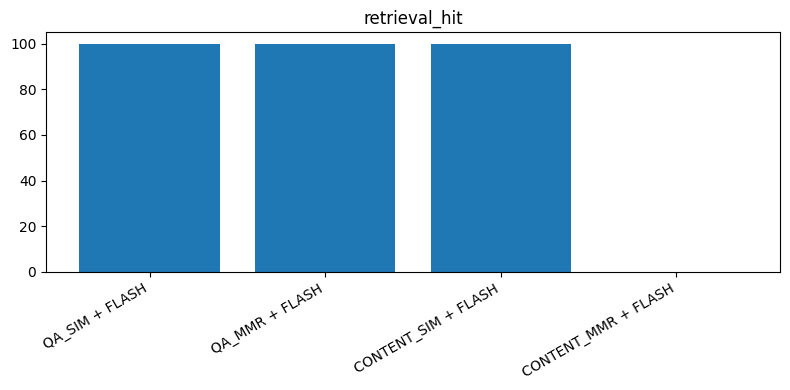

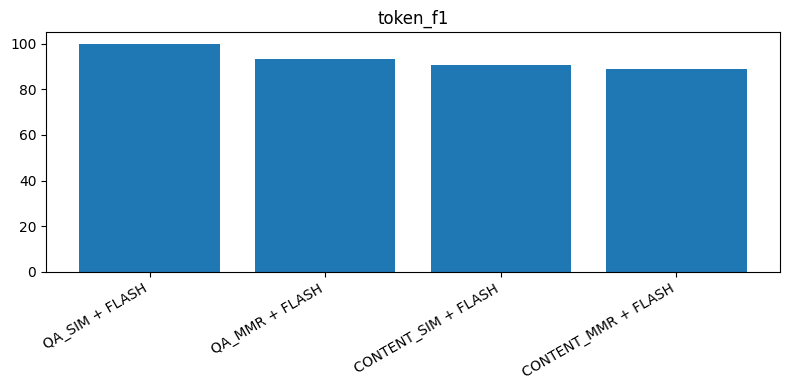

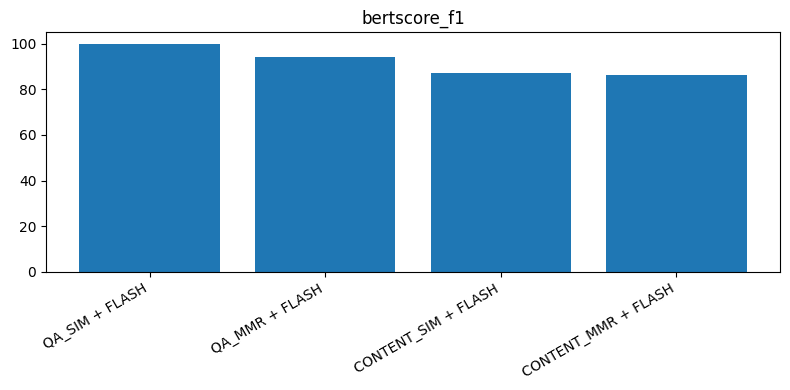

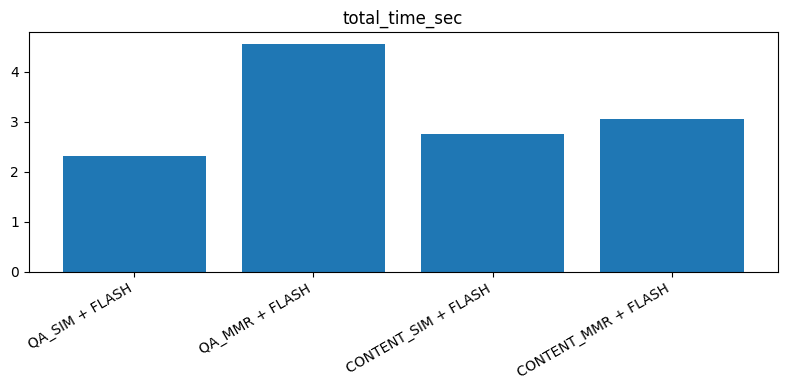

In [ ]:
import matplotlib.pyplot as plt

plot_df = summary_df.copy()
metrics = ["retrieval_hit", "token_f1", "bertscore_f1", "total_time_sec"]

for metric in metrics:
    plt.figure(figsize=(8, 4))
    plt.bar(plot_df["mode"], plot_df[metric])
    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

Cell 31 — Cấu hình ngưỡng “gần đúng là đạt”

In [26]:
ACCEPTABLE_TOKEN_F1_THRESHOLD = 0.45
ACCEPTABLE_BERTSCORE_THRESHOLD = 0.85

Cell 32 — Hàm chấm “acceptable / near-correct”

In [27]:
def acceptable_match(pred, gold, soft_contains_value, token_f1_value, bertscore_value):
    return int(
        (soft_contains_value == 1) or
        (token_f1_value >= ACCEPTABLE_TOKEN_F1_THRESHOLD) or
        (bertscore_value >= ACCEPTABLE_BERTSCORE_THRESHOLD)
    )

def score_prediction(pred, gold, context=""):
    em = exact_match(pred, gold)
    sc = soft_contains(pred, gold)
    tf1 = token_f1(pred, gold)
    bs = bertscore_f1_single(pred, gold)
    rh = retrieval_hit(context, gold) if context is not None else 0
    acc = acceptable_match(pred, gold, sc, tf1, bs)

    return {
        "exact_match": em,
        "soft_contains": sc,
        "token_f1": tf1,
        "bertscore_f1": bs,
        "retrieval_hit": rh,
        "acceptable_match": acc
    }

Cell 33 — Test 1: câu hỏi có sẵn trong bộ QA

Đây là test “in-set exact question”.

In [28]:
exact_question_test_df = qa_df_small.copy()
exact_question_test_df["test_type"] = "exact_question_in_qa"
exact_question_test_df["original_question"] = exact_question_test_df["question"]

print("Exact-question test size:", len(exact_question_test_df))
exact_question_test_df.head()

Exact-question test size: 30


,qa_id,question,gold_answer,test_type,original_question
0,1,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,exact_question_in_qa,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...
1,2,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động được thực hiện trên cơ...,exact_question_in_qa,Việc phối hợp hoạt động trong công tác hòa giả...
2,3,Trong công tác hòa giải ở cơ sở cần phát huy v...,Cần phát huy vai trò nòng cốt của Mặt trận Tổ ...,exact_question_in_qa,Trong công tác hòa giải ở cơ sở cần phát huy v...
3,4,Việc phối hợp trong công tác hòa giải ở cơ sở ...,"Việc phối hợp phải thường xuyên, kịp thời, đồn...",exact_question_in_qa,Việc phối hợp trong công tác hòa giải ở cơ sở ...
4,5,Ai tham gia đóng góp ý kiến về dự thảo văn bản...,Ủy ban Trung ương Mặt trận Tổ quốc Việt Nam và...,exact_question_in_qa,Ai tham gia đóng góp ý kiến về dự thảo văn bản...


Cell 34 — Test 2: câu hỏi tương tự bộ QA

Ở đây mình chỉ lấy paraphrase, bỏ câu gốc ra.

In [29]:
similar_question_rows = []

for _, row in qa_df_small.iterrows():
    variants = make_paraphrases(row["question"])
    for q in variants:
        if normalize_text(q) != normalize_text(row["question"]):
            similar_question_rows.append({
                "qa_id": row["qa_id"],
                "question": q,
                "gold_answer": row["gold_answer"],
                "original_question": row["question"],
                "test_type": "similar_question_from_qa"
            })

similar_question_test_df = pd.DataFrame(similar_question_rows).drop_duplicates().reset_index(drop=True)

print("Similar-question test size:", len(similar_question_test_df))
similar_question_test_df.head(10)

Similar-question test size: 40


,qa_id,question,gold_answer,original_question,test_type
0,1,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,similar_question_from_qa
1,1,Cho tôi biết: Nghị quyết liên tịch 01/2014/NQL...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,similar_question_from_qa
2,2,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động được thực hiện trên cơ...,Việc phối hợp hoạt động trong công tác hòa giả...,similar_question_from_qa
3,2,Cho tôi biết: Việc phối hợp hoạt động trong cô...,Việc phối hợp hoạt động được thực hiện trên cơ...,Việc phối hợp hoạt động trong công tác hòa giả...,similar_question_from_qa
4,3,Cho tôi biết: Trong công tác hòa giải ở cơ sở ...,Cần phát huy vai trò nòng cốt của Mặt trận Tổ ...,Trong công tác hòa giải ở cơ sở cần phát huy v...,similar_question_from_qa
5,4,Cho tôi biết: Việc phối hợp trong công tác hòa...,"Việc phối hợp phải thường xuyên, kịp thời, đồn...",Việc phối hợp trong công tác hòa giải ở cơ sở ...,similar_question_from_qa
6,5,Cho tôi biết: Ai tham gia đóng góp ý kiến về d...,Ủy ban Trung ương Mặt trận Tổ quốc Việt Nam và...,Ai tham gia đóng góp ý kiến về dự thảo văn bản...,similar_question_from_qa
7,6,Cho tôi biết: Các tổ chức thành viên của Mặt t...,Các tổ chức thành viên của Mặt trận tham gia t...,Các tổ chức thành viên của Mặt trận có vai trò...,similar_question_from_qa
8,7,Ai chịu trách nhiệm phổ biến và vận động nhân ...,Ủy ban Mặt trận Tổ quốc Việt Nam và các tổ chứ...,Ai có trách nhiệm phổ biến và vận động nhân dâ...,similar_question_from_qa
9,7,Cho tôi biết: Ai có trách nhiệm phổ biến và vậ...,Ủy ban Mặt trận Tổ quốc Việt Nam và các tổ chứ...,Ai có trách nhiệm phổ biến và vận động nhân dâ...,similar_question_from_qa


Cell 35 — Test 3: câu hỏi ngoài bộ QA nhưng nội dung liên quan

Mình tạo sẵn một bộ câu hỏi không nằm trong QA file, nhưng vẫn liên quan trực tiếp đến file nội dung đầu tiên.

In [30]:
ood_related_test_df = pd.DataFrame([
    {
        "question": "Trong bao lâu trước ngày dự kiến bầu hòa giải viên thì phải chuẩn bị bầu?",
        "gold_answer": "Trong thời hạn 20 ngày, trước ngày dự kiến bầu hòa giải viên, Trưởng ban công tác Mặt trận chủ trì, phối hợp với trưởng thôn, tổ trưởng tổ dân phố, đại diện các tổ chức thành viên của Mặt trận dự kiến những người được bầu làm hòa giải viên và chuẩn bị việc bầu.",
        "original_question": "OOD_1",
        "test_type": "out_of_set_related"
    },
    {
        "question": "Nếu bầu lại hoặc bầu bổ sung hòa giải viên bằng hình thức phát phiếu thì thời gian tổ chức là bao lâu?",
        "gold_answer": "Trường hợp bầu hòa giải viên bằng hình thức phát phiếu lấy ý kiến các hộ gia đình, thì thời gian tổ chức bầu lại hoặc bầu bổ sung hòa giải viên do Trưởng ban công tác Mặt trận quyết định trong thời hạn 30 ngày, kể từ ngày tổ chức bầu trước đó.",
        "original_question": "OOD_2",
        "test_type": "out_of_set_related"
    },
    {
        "question": "Nếu tổ hòa giải đã đủ số lượng nhưng chưa có hòa giải viên nữ hoặc người dân tộc thiểu số thì xử lý thế nào?",
        "gold_answer": "Trưởng ban công tác Mặt trận làm văn bản báo cáo Chủ tịch Ủy ban nhân dân cấp xã; trong thời hạn 05 ngày làm việc, Chủ tịch Ủy ban nhân dân cấp xã xem xét, quyết định việc bầu bổ sung hòa giải viên nữ hoặc hòa giải viên là người dân tộc thiểu số.",
        "original_question": "OOD_3",
        "test_type": "out_of_set_related"
    },
    {
        "question": "Sau cuộc họp bầu tổ trưởng tổ hòa giải, trong bao lâu phải gửi văn bản đề nghị công nhận?",
        "gold_answer": "Trong thời hạn 05 ngày, kể từ ngày tổ chức cuộc họp bầu tổ trưởng tổ hòa giải, Trưởng ban công tác Mặt trận làm văn bản đề nghị công nhận tổ trưởng tổ hòa giải gửi Chủ tịch Ủy ban nhân dân cấp xã.",
        "original_question": "OOD_4",
        "test_type": "out_of_set_related"
    }
])

print("OOD related test size:", len(ood_related_test_df))
ood_related_test_df

OOD related test size: 4


,question,gold_answer,original_question,test_type
0,Trong bao lâu trước ngày dự kiến bầu hòa giải ...,"Trong thời hạn 20 ngày, trước ngày dự kiến bầu...",OOD_1,out_of_set_related
1,Nếu bầu lại hoặc bầu bổ sung hòa giải viên bằn...,Trường hợp bầu hòa giải viên bằng hình thức ph...,OOD_2,out_of_set_related
2,Nếu tổ hòa giải đã đủ số lượng nhưng chưa có h...,Trưởng ban công tác Mặt trận làm văn bản báo c...,OOD_3,out_of_set_related
3,"Sau cuộc họp bầu tổ trưởng tổ hòa giải, trong ...","Trong thời hạn 05 ngày, kể từ ngày tổ chức cuộ...",OOD_4,out_of_set_related


In [31]:
exact_question_test_df_small = exact_question_test_df.head(3).copy()
similar_question_test_df_small = similar_question_test_df.head(3).copy()
ood_related_test_df_small = ood_related_test_df.head(3).copy()

print("Defined _small versions of test dataframes.")

Defined _small versions of test dataframes.


Cell 36 — Hàm đánh giá 1 test set cho 1 mode

In [32]:
def evaluate_test_set(mode_name, retriever, llm, source_name, test_df):
    rows = []

    for i, (_, row) in enumerate(test_df.iterrows(), start=1):
        print(f"[{mode_name}] {row['test_type']} {i}/{len(test_df)}")

        result = ask_from_source(
            question=row["question"],
            retriever=retriever,
            llm=llm,
            source_name=source_name
        )

        pred = result["answer"]
        gold = row["gold_answer"]

        scores = score_prediction(pred, gold, context=result["context"])

        rows.append({
            "mode": mode_name,
            "source_type": source_name,
            "test_type": row["test_type"],
            "question": row["question"],
            "original_question": row["original_question"],
            "gold_answer": gold,
            "pred_answer": pred,
            "retrieval_hit": scores["retrieval_hit"],
            "exact_match": scores["exact_match"],
            "soft_contains": scores["soft_contains"],
            "token_f1": scores["token_f1"],
            "bertscore_f1": scores["bertscore_f1"],
            "acceptable_match": scores["acceptable_match"],
            "retrieval_time_sec": result["retrieval_time_sec"],
            "generation_time_sec": result["generation_time_sec"],
            "total_time_sec": result["total_time_sec"],
        })

    return pd.DataFrame(rows)

Cell 37 — Chọn mode để test

Để tiết kiệm API miễn phí,  test 2 mode chính:

CONTENT_SIM + FLASH
QA_SIM + FLASH

In [33]:
TEST_MODES = {
    "CONTENT_SIM + FLASH": (content_retriever_sim, llm_flash, "content"),
    "QA_SIM + FLASH": (qa_retriever_sim, llm_flash, "qa"),
}

Cell 38 — Chạy Test 1: câu hỏi có trong bộ QA

In [ ]:
exact_results = []

for mode_name, (retriever, llm, source_name) in TEST_MODES.items():
    df_mode = evaluate_test_set(
        mode_name=mode_name,
        retriever=retriever,
        llm=llm,
        source_name=source_name,
        test_df=exact_question_test_df
    )
    exact_results.append(df_mode)

exact_results_df = pd.concat(exact_results, ignore_index=True)
exact_results_df.head()

[CONTENT_SIM + FLASH] exact_question_in_qa 1/30


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[CONTENT_SIM + FLASH] exact_question_in_qa 2/30


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_2475/1144482722.py", line 4, in <cell line: 0>
    df_mode = evaluate_test_set(
              ^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2475/3836496960.py", line 7, in evaluate_test_set
    result = ask_from_source(
             ^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2475/2417555140.py", line 30, in ask_from_source
    resp = safe_call(
           ^^^^^^^^^^
  File "/tmp/ipykernel_2475/4016740209.py", line 24, in safe_call
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/langchain_core/language_models/chat_models.py", line 277, in invoke
    self.generate_prompt(
  File "/usr/local/lib/python3.12/dist-packages/langchain_core/language_models/chat_models.py", line 777, in generate_prompt
    return self.gener

TypeError: object of type 'NoneType' has no len()

In [ ]:
exact_results = []

exact_question_test_df_small = exact_question_test_df.head(3).copy()

for mode_name, (retriever, llm, source_name) in TEST_MODES.items():
    df_mode = evaluate_test_set(
        mode_name=mode_name,
        retriever=retriever,
        llm=llm,
        source_name=source_name,
        test_df=exact_question_test_df_small
    )
    exact_results.append(df_mode)

exact_results_df = pd.concat(exact_results, ignore_index=True)
exact_results_df.head()

[CONTENT_SIM + FLASH] exact_question_in_qa 1/3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[CONTENT_SIM + FLASH] exact_question_in_qa 2/3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[QA_SIM + FLASH] exact_question_in_qa 3/3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,mode,source_type,test_type,question,original_question,gold_answer,pred_answer,retrieval_hit,exact_match,soft_contains,token_f1,bertscore_f1,acceptable_match,retrieval_time_sec,generation_time_sec,total_time_sec
0,CONTENT_SIM + FLASH,content,exact_question_in_qa,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,1,0,0,0.906977,0.870742,1,0.385442,2.650563,3.036005
1,CONTENT_SIM + FLASH,content,exact_question_in_qa,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động được thực hiện trên cơ...,Việc phối hợp hoạt động được thực hiện trên cơ...,0,0,0,0.945455,0.995820,1,0.394418,2.200733,2.595152
2,CONTENT_SIM + FLASH,content,exact_question_in_qa,Trong công tác hòa giải ở cơ sở cần phát huy v...,Trong công tác hòa giải ở cơ sở cần phát huy v...,Cần phát huy vai trò nòng cốt của Mặt trận Tổ ...,Trong công tác hòa giải ở cơ sở cần phát huy v...,0,0,0,0.441860,0.747116,0,0.412699,12.856059,13.268758
3,QA_SIM + FLASH,qa,exact_question_in_qa,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,1,1,1,1.000000,1.000000,1,0.415966,1.769886,2.185852
4,QA_SIM + FLASH,qa,exact_question_in_qa,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động được thực hiện trên cơ...,Việc phối hợp hoạt động được thực hiện trên cơ...,1,1,1,1.000000,1.000000,1,0.390164,1.730461,2.120625


Cell 39 — Chạy Test 2: câu hỏi tương tự bộ QA

In [ ]:
similar_results = []

similar_question_test_df_small = similar_question_test_df.head(3).copy()

for mode_name, (retriever, llm, source_name) in TEST_MODES.items():
    df_mode = evaluate_test_set(
        mode_name=mode_name,
        retriever=retriever,
        llm=llm,
        source_name=source_name,
        test_df=similar_question_test_df_small
    )
    similar_results.append(df_mode)

similar_results_df = pd.concat(similar_results, ignore_index=True)
similar_results_df.head()

[CONTENT_SIM + FLASH] similar_question_from_qa 1/3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[CONTENT_SIM + FLASH] similar_question_from_qa 2/3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 19.348525924s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 19
}
].


[Retry 5/5] sleep 129.2s because: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 17.070322569s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 17
}
]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,mode,source_type,test_type,question,original_question,gold_answer,pred_answer,retrieval_hit,exact_match,soft_contains,token_f1,bertscore_f1,acceptable_match,retrieval_time_sec,generation_time_sec,total_time_sec
0,CONTENT_SIM + FLASH,content,similar_question_from_qa,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,1,0,0,0.906977,0.870742,1,0.375471,2.008553,2.384024
1,CONTENT_SIM + FLASH,content,similar_question_from_qa,Cho tôi biết: Nghị quyết liên tịch 01/2014/NQL...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,1,0,0,0.906977,0.870742,1,0.390338,2.516542,2.906879
2,CONTENT_SIM + FLASH,content,similar_question_from_qa,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động được thực hiện trên cơ...,Điều 2 01/2014/NQLT/CP-UBTƯMTTQVN hướng dẫn ph...,0,0,0,0.245614,0.652538,0,0.386819,266.471566,266.858384
3,QA_SIM + FLASH,qa,similar_question_from_qa,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,1,0,1,0.713178,0.805602,1,0.409105,266.521139,266.930244
4,QA_SIM + FLASH,qa,similar_question_from_qa,Cho tôi biết: Nghị quyết liên tịch 01/2014/NQL...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,1,0,1,0.713178,0.835577,1,0.407128,266.914478,267.321605


Cell 40 — Chạy Test 3: câu hỏi ngoài bộ QA nhưng liên quan nội dung

In [ ]:
ood_results = []

ood_related_test_df_small = ood_related_test_df.head(3).copy()

for mode_name, (retriever, llm, source_name) in TEST_MODES.items():
    df_mode = evaluate_test_set(
        mode_name=mode_name,
        retriever=retriever,
        llm=llm,
        source_name=source_name,
        test_df=ood_related_test_df_small
    )
    ood_results.append(df_mode)

ood_results_df = pd.concat(ood_results, ignore_index=True)
ood_results_df.head()

[CONTENT_SIM + FLASH] out_of_set_related 1/3


* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 25.866085855s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 25
}
].


[Retry 1/5] sleep 9.1s because: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 23.558075435s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 23
}
]


* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 14.207779182s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 14
}
].


[Retry 2/5] sleep 16.8s because: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 11.882184385s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 11
}
]


...

* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 20.844979478s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 20
}
].


[Retry 5/5] sleep 128.6s because: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 18.51539306s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 18
}
]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,mode,source_type,test_type,question,original_question,gold_answer,pred_answer,retrieval_hit,exact_match,soft_contains,token_f1,bertscore_f1,acceptable_match,retrieval_time_sec,generation_time_sec,total_time_sec
0,CONTENT_SIM + FLASH,content,out_of_set_related,Trong bao lâu trước ngày dự kiến bầu hòa giải ...,OOD_1,"Trong thời hạn 20 ngày, trước ngày dự kiến bầu...",Điều 12 01/2014/NQLT/CP-UBTƯMTTQVN hướng dẫn p...,1,0,0,0.318519,0.735690,0,0.401748,266.552611,266.954359
1,CONTENT_SIM + FLASH,content,out_of_set_related,Nếu bầu lại hoặc bầu bổ sung hòa giải viên bằn...,OOD_2,Trường hợp bầu hòa giải viên bằng hình thức ph...,Điều 12 01/2014/NQLT/CP-UBTƯMTTQVN hướng dẫn p...,1,0,1,0.332103,0.731952,1,0.349299,266.814504,267.163803
2,CONTENT_SIM + FLASH,content,out_of_set_related,Nếu tổ hòa giải đã đủ số lượng nhưng chưa có h...,OOD_3,Trưởng ban công tác Mặt trận làm văn bản báo c...,Điều 12 01/2014/NQLT/CP-UBTƯMTTQVN hướng dẫn p...,1,0,0,0.307116,0.722902,0,0.364885,267.284007,267.648892
3,QA_SIM + FLASH,qa,out_of_set_related,Trong bao lâu trước ngày dự kiến bầu hòa giải ...,OOD_1,"Trong thời hạn 20 ngày, trước ngày dự kiến bầu...",Trưởng ban công tác Mặt trận phối hợp với các ...,1,0,0,0.537634,0.742026,1,0.399108,265.979387,266.378495
4,QA_SIM + FLASH,qa,out_of_set_related,Nếu bầu lại hoặc bầu bổ sung hòa giải viên bằn...,OOD_2,Trường hợp bầu hòa giải viên bằng hình thức ph...,Việc bầu tổ trưởng tổ hòa giải được tổ chức kh...,1,0,0,0.350515,0.695489,0,0.363712,266.850892,267.214603


Cell 41 — Hàm summary cho từng test

In [ ]:
def summarize_test_results(df, test_name):
    summary = (
        df.groupby("mode")
        .agg({
            "acceptable_match": "mean",
            "exact_match": "mean",
            "soft_contains": "mean",
            "token_f1": "mean",
            "bertscore_f1": "mean",
            "retrieval_hit": "mean",
            "retrieval_time_sec": "mean",
            "generation_time_sec": "mean",
            "total_time_sec": "mean"
        })
        .reset_index()
    )

    for col in ["acceptable_match", "exact_match", "soft_contains", "token_f1", "bertscore_f1", "retrieval_hit"]:
        summary[col] = (summary[col] * 100).round(2)

    print(f"\n===== {test_name} =====")
    return summary.sort_values(by=["acceptable_match", "bertscore_f1"], ascending=False)

Cell 42 — Xem kết quả 3 test

In [ ]:
exact_summary = summarize_test_results(exact_results_df, "TEST 1 - Exact questions in QA")
similar_summary = summarize_test_results(similar_results_df, "TEST 2 - Similar questions to QA")
ood_summary = summarize_test_results(ood_results_df, "TEST 3 - Out-of-set but related questions")

exact_summary, similar_summary, ood_summary


===== TEST 1 - Exact questions in QA =====

===== TEST 2 - Similar questions to QA =====

===== TEST 3 - Out-of-set but related questions =====


(                  mode  acceptable_match  exact_match  soft_contains  \
 1       QA_SIM + FLASH            100.00        100.0          100.0   
 0  CONTENT_SIM + FLASH             66.67          0.0            0.0   
 
    token_f1  bertscore_f1  retrieval_hit  retrieval_time_sec  \
 1    100.00        100.00         100.00            0.391717   
 0     76.48         87.12          33.33            0.397520   
 
    generation_time_sec  total_time_sec  
 1             1.594251        1.985968  
 0             5.902452        6.299972  ,
                   mode  acceptable_match  exact_match  soft_contains  \
 1       QA_SIM + FLASH            100.00          0.0          100.0   
 0  CONTENT_SIM + FLASH             66.67          0.0            0.0   
 
    token_f1  bertscore_f1  retrieval_hit  retrieval_time_sec  \
 1     66.03         80.97         100.00            0.397870   
 0     68.65         79.80          66.67            0.384209   
 
    generation_time_sec  total_time_s

Cell 43 — Tính % câu trả lời gần đúng hoặc đúng

In [ ]:
print("TEST 1 - Exact questions")
display(exact_summary[["mode", "acceptable_match", "exact_match", "token_f1", "bertscore_f1", "total_time_sec"]])

print("TEST 2 - Similar questions")
display(similar_summary[["mode", "acceptable_match", "exact_match", "token_f1", "bertscore_f1", "total_time_sec"]])

print("TEST 3 - Out-of-set but related questions")
display(ood_summary[["mode", "acceptable_match", "exact_match", "token_f1", "bertscore_f1", "total_time_sec"]])

TEST 1 - Exact questions


,mode,acceptable_match,exact_match,token_f1,bertscore_f1,total_time_sec
1,QA_SIM + FLASH,100.00,100.0,100.00,100.00,1.985968
0,CONTENT_SIM + FLASH,66.67,0.0,76.48,87.12,6.299972


TEST 2 - Similar questions


,mode,acceptable_match,exact_match,token_f1,bertscore_f1,total_time_sec
1,QA_SIM + FLASH,100.00,0.0,66.03,80.97,267.311811
0,CONTENT_SIM + FLASH,66.67,0.0,68.65,79.80,90.716429


TEST 3 - Out-of-set but related questions


,mode,acceptable_match,exact_match,token_f1,bertscore_f1,total_time_sec
0,CONTENT_SIM + FLASH,33.33,0.0,31.92,73.02,267.255685
1,QA_SIM + FLASH,33.33,0.0,39.43,70.47,266.551606


Cell 44 — Gộp tất cả kết quả

In [ ]:
all_test_results_df = pd.concat(
    [exact_results_df, similar_results_df, ood_results_df],
    ignore_index=True
)

all_test_results_df.head()

,mode,source_type,test_type,question,original_question,gold_answer,pred_answer,retrieval_hit,exact_match,soft_contains,token_f1,bertscore_f1,acceptable_match,retrieval_time_sec,generation_time_sec,total_time_sec
0,CONTENT_SIM + FLASH,content,exact_question_in_qa,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,1,0,0,0.906977,0.870742,1,0.385442,2.650563,3.036005
1,CONTENT_SIM + FLASH,content,exact_question_in_qa,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động được thực hiện trên cơ...,Việc phối hợp hoạt động được thực hiện trên cơ...,0,0,0,0.945455,0.995820,1,0.394418,2.200733,2.595152
2,CONTENT_SIM + FLASH,content,exact_question_in_qa,Trong công tác hòa giải ở cơ sở cần phát huy v...,Trong công tác hòa giải ở cơ sở cần phát huy v...,Cần phát huy vai trò nòng cốt của Mặt trận Tổ ...,Trong công tác hòa giải ở cơ sở cần phát huy v...,0,0,0,0.441860,0.747116,0,0.412699,12.856059,13.268758
3,QA_SIM + FLASH,qa,exact_question_in_qa,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,1,1,1,1.000000,1.000000,1,0.415966,1.769886,2.185852
4,QA_SIM + FLASH,qa,exact_question_in_qa,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động trong công tác hòa giả...,Việc phối hợp hoạt động được thực hiện trên cơ...,Việc phối hợp hoạt động được thực hiện trên cơ...,1,1,1,1.000000,1.000000,1,0.390164,1.730461,2.120625


Cell 45 — Xuất file kết quả

In [ ]:
with pd.ExcelWriter("/content/three_test_evaluation.xlsx", engine="openpyxl") as writer:
    exact_results_df.to_excel(writer, sheet_name="test1_exact_detail", index=False)
    similar_results_df.to_excel(writer, sheet_name="test2_similar_detail", index=False)
    ood_results_df.to_excel(writer, sheet_name="test3_ood_detail", index=False)

    exact_summary.to_excel(writer, sheet_name="test1_exact_summary", index=False)
    similar_summary.to_excel(writer, sheet_name="test2_similar_summary", index=False)
    ood_summary.to_excel(writer, sheet_name="test3_ood_summary", index=False)

print("Saved: /content/three_test_evaluation.xlsx")

Saved: /content/three_test_evaluation.xlsx


Code dùng cho một bảng kết quả bất kỳ

Ví dụ áp dụng cho:

exact_results_df
similar_results_df
ood_results_df

In [ ]:
def summarize_accuracy_table(df, title="Summary"):
    summary = (
        df.groupby("mode")
        .agg(
            total_questions=("mode", "size"),
            exact_match_count=("exact_match", "sum"),
            acceptable_count=("acceptable_match", "sum"),
            exact_match_percent=("exact_match", lambda x: round(x.mean() * 100, 2)),
            acceptable_percent=("acceptable_match", lambda x: round(x.mean() * 100, 2)),
            avg_token_f1=("token_f1", lambda x: round(x.mean(), 4)),
            avg_bertscore_f1=("bertscore_f1", lambda x: round(x.mean(), 4)),
            avg_total_time_sec=("total_time_sec", lambda x: round(x.mean(), 4)),
        )
        .reset_index()
    )

    # đánh dấu mode có exact cao nhất
    max_exact = summary["exact_match_percent"].max()
    summary["best_exact_match"] = summary["exact_match_percent"].apply(
        lambda x: "Best" if x == max_exact else ""
    )

    # đánh dấu mode có acceptable cao nhất
    max_acceptable = summary["acceptable_percent"].max()
    summary["best_acceptable_match"] = summary["acceptable_percent"].apply(
        lambda x: "Best" if x == max_acceptable else ""
    )

    print(f"\n===== {title} =====")
    return summary.sort_values(
        by=["acceptable_percent", "exact_match_percent", "avg_bertscore_f1"],
        ascending=False
    ).reset_index(drop=True)

Dùng cho 3 bộ test
1. Exact questions

In [ ]:
exact_accuracy_summary = summarize_accuracy_table(
    exact_results_df,
    title="Exact Questions"
)
exact_accuracy_summary


===== Exact Questions =====


,mode,total_questions,exact_match_count,acceptable_count,exact_match_percent,acceptable_percent,avg_token_f1,avg_bertscore_f1,avg_total_time_sec,best_exact_match,best_acceptable_match
0,QA_SIM + FLASH,3,3,3,100.0,100.00,1.0000,1.0000,1.986,Best,Best
1,CONTENT_SIM + FLASH,3,0,2,0.0,66.67,0.7648,0.8712,6.300,,


2. Similar questions

In [ ]:
similar_accuracy_summary = summarize_accuracy_table(
    similar_results_df,
    title="Similar Questions"
)
similar_accuracy_summary


===== Similar Questions =====


,mode,total_questions,exact_match_count,acceptable_count,exact_match_percent,acceptable_percent,avg_token_f1,avg_bertscore_f1,avg_total_time_sec,best_exact_match,best_acceptable_match
0,QA_SIM + FLASH,3,0,3,0.0,100.00,0.6603,0.8097,267.3118,Best,Best
1,CONTENT_SIM + FLASH,3,0,2,0.0,66.67,0.6865,0.7980,90.7164,Best,


3. Out-of-set related questions

In [ ]:
ood_accuracy_summary = summarize_accuracy_table(
    ood_results_df,
    title="Out-of-set Related Questions"
)
ood_accuracy_summary


===== Out-of-set Related Questions =====


,mode,total_questions,exact_match_count,acceptable_count,exact_match_percent,acceptable_percent,avg_token_f1,avg_bertscore_f1,avg_total_time_sec,best_exact_match,best_acceptable_match
0,CONTENT_SIM + FLASH,3,0,1,0.0,33.33,0.3192,0.7302,267.2557,Best,Best
1,QA_SIM + FLASH,3,0,1,0.0,33.33,0.3943,0.7047,266.5516,Best,Best


Mode cao nhất

In [ ]:
def print_best_modes(summary_df, label):
    best_exact_row = summary_df.loc[summary_df["exact_match_percent"].idxmax()]
    best_acceptable_row = summary_df.loc[summary_df["acceptable_percent"].idxmax()]

    print(f"\n[{label}]")
    print(f"Best exact match mode: {best_exact_row['mode']} ({best_exact_row['exact_match_percent']}%)")
    print(f"Best acceptable match mode: {best_acceptable_row['mode']} ({best_acceptable_row['acceptable_percent']}%)")

In [ ]:
print_best_modes(exact_accuracy_summary, "Exact Questions")
print_best_modes(similar_accuracy_summary, "Similar Questions")
print_best_modes(ood_accuracy_summary, "Out-of-set Related Questions")


[Exact Questions]
Best exact match mode: QA_SIM + FLASH (100.0%)
Best acceptable match mode: QA_SIM + FLASH (100.0%)

[Similar Questions]
Best exact match mode: QA_SIM + FLASH (0.0%)
Best acceptable match mode: QA_SIM + FLASH (100.0%)

[Out-of-set Related Questions]
Best exact match mode: CONTENT_SIM + FLASH (0.0%)
Best acceptable match mode: CONTENT_SIM + FLASH (33.33%)


Cell 1 — Tạo 3 bộ benchmark, mỗi bộ 3 câu

In [34]:
import pandas as pd

# 1) EXACT QUESTIONS: y hệt hoặc rất sát bộ QA
exact_question_test_df_3 = pd.DataFrame([
    {
        "question": "Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQVN điều chỉnh những nội dung gì?",
        "gold_answer": "Nghị quyết liên tịch này hướng dẫn phối hợp thực hiện một số quy định của pháp luật về hòa giải ở cơ sở, trong đó đề cập đến tổ chức, hoạt động hòa giải ở cơ sở và tham gia quản lý nhà nước về hòa giải ở cơ sở của Mặt trận Tổ quốc Việt Nam.",
        "original_question": "Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQVN điều chỉnh những nội dung gì?",
        "test_type": "exact_question"
    },
    {
        "question": "Việc sơ kết và tổng kết về hòa giải ở cơ sở được thực hiện với tần suất như thế nào?",
        "gold_answer": "Việc sơ kết về hòa giải ở cơ sở được thực hiện hàng năm và tổng kết được thực hiện mỗi 5 năm một lần.",
        "original_question": "Việc sơ kết và tổng kết về hòa giải ở cơ sở được thực hiện với tần suất như thế nào?",
        "test_type": "exact_question"
    },
    {
        "question": "Nghị quyết này có hiệu lực thi hành từ ngày nào?",
        "gold_answer": "Nghị quyết này có hiệu lực thi hành từ ngày 10 tháng 01 năm 2015.",
        "original_question": "Nghị quyết này có hiệu lực thi hành từ ngày nào?",
        "test_type": "exact_question"
    }
])

# 2) SIMILAR QUESTIONS: cùng ý nghĩa, khác wording
similar_question_test_df_3 = pd.DataFrame([
    {
        "question": "Văn bản này quy định những vấn đề gì?",
        "gold_answer": "Nghị quyết liên tịch này hướng dẫn phối hợp thực hiện một số quy định của pháp luật về hòa giải ở cơ sở, trong đó đề cập đến tổ chức, hoạt động hòa giải ở cơ sở và tham gia quản lý nhà nước về hòa giải ở cơ sở của Mặt trận Tổ quốc Việt Nam.",
        "original_question": "Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQVN điều chỉnh những nội dung gì?",
        "test_type": "similar_question"
    },
    {
        "question": "Bao lâu thì hoạt động hòa giải ở cơ sở được sơ kết và tổng kết?",
        "gold_answer": "Việc sơ kết về hòa giải ở cơ sở được thực hiện hàng năm và tổng kết được thực hiện mỗi 5 năm một lần.",
        "original_question": "Việc sơ kết và tổng kết về hòa giải ở cơ sở được thực hiện với tần suất như thế nào?",
        "test_type": "similar_question"
    },
    {
        "question": "Khi nào Nghị quyết này bắt đầu có hiệu lực?",
        "gold_answer": "Nghị quyết này có hiệu lực thi hành từ ngày 10 tháng 01 năm 2015.",
        "original_question": "Nghị quyết này có hiệu lực thi hành từ ngày nào?",
        "test_type": "similar_question"
    }
])

# 3) OUT-OF-SET BUT RELATED: không có nguyên văn trong QA nhưng liên quan nội dung
ood_related_test_df_3 = pd.DataFrame([
    {
        "question": "Trong bao lâu trước ngày dự kiến bầu hòa giải viên thì phải chuẩn bị việc bầu?",
        "gold_answer": "Trong thời hạn 20 ngày, trước ngày dự kiến bầu hòa giải viên, Trưởng ban công tác Mặt trận chủ trì, phối hợp với trưởng thôn, tổ trưởng tổ dân phố, đại diện các tổ chức thành viên của Mặt trận dự kiến những người được bầu làm hòa giải viên và chuẩn bị việc bầu.",
        "original_question": "OOD_bau_hoa_giai_vien_1",
        "test_type": "out_of_set_related"
    },
    {
        "question": "Nếu bầu lại hoặc bầu bổ sung hòa giải viên bằng hình thức phát phiếu thì thời gian tổ chức là bao lâu?",
        "gold_answer": "Trường hợp bầu hòa giải viên bằng hình thức phát phiếu lấy ý kiến các hộ gia đình, thì thời gian tổ chức bầu lại hoặc bầu bổ sung hòa giải viên do Trưởng ban công tác Mặt trận quyết định trong thời hạn 30 ngày, kể từ ngày tổ chức bầu trước đó.",
        "original_question": "OOD_bau_hoa_giai_vien_2",
        "test_type": "out_of_set_related"
    },
    {
        "question": "Sau cuộc họp bầu tổ trưởng tổ hòa giải, trong bao lâu phải gửi văn bản đề nghị công nhận?",
        "gold_answer": "Trong thời hạn 05 ngày, kể từ ngày tổ chức cuộc họp bầu tổ trưởng tổ hòa giải, Trưởng ban công tác Mặt trận làm văn bản đề nghị công nhận tổ trưởng tổ hòa giải gửi Chủ tịch Ủy ban nhân dân cấp xã.",
        "original_question": "OOD_to_truong_to_hoa_giai",
        "test_type": "out_of_set_related"
    }
])

print("Exact:", len(exact_question_test_df_3))
print("Similar:", len(similar_question_test_df_3))
print("OOD related:", len(ood_related_test_df_3))

Exact: 3
Similar: 3
OOD related: 3


In [35]:
print("Content of exact_question_test_df_3:")
display(exact_question_test_df_3)

print("Content of similar_question_test_df_3:")
display(similar_question_test_df_3)

print("Content of ood_related_test_df_3:")
display(ood_related_test_df_3)

Content of exact_question_test_df_3:


,question,gold_answer,original_question,test_type
0,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,exact_question
1,Việc sơ kết và tổng kết về hòa giải ở cơ sở đư...,Việc sơ kết về hòa giải ở cơ sở được thực hiện...,Việc sơ kết và tổng kết về hòa giải ở cơ sở đư...,exact_question
2,Nghị quyết này có hiệu lực thi hành từ ngày nào?,Nghị quyết này có hiệu lực thi hành từ ngày 10...,Nghị quyết này có hiệu lực thi hành từ ngày nào?,exact_question


Content of similar_question_test_df_3:


,question,gold_answer,original_question,test_type
0,Văn bản này quy định những vấn đề gì?,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,similar_question
1,Bao lâu thì hoạt động hòa giải ở cơ sở được sơ...,Việc sơ kết về hòa giải ở cơ sở được thực hiện...,Việc sơ kết và tổng kết về hòa giải ở cơ sở đư...,similar_question
2,Khi nào Nghị quyết này bắt đầu có hiệu lực?,Nghị quyết này có hiệu lực thi hành từ ngày 10...,Nghị quyết này có hiệu lực thi hành từ ngày nào?,similar_question


Content of ood_related_test_df_3:


,question,gold_answer,original_question,test_type
0,Trong bao lâu trước ngày dự kiến bầu hòa giải ...,"Trong thời hạn 20 ngày, trước ngày dự kiến bầu...",OOD_bau_hoa_giai_vien_1,out_of_set_related
1,Nếu bầu lại hoặc bầu bổ sung hòa giải viên bằn...,Trường hợp bầu hòa giải viên bằng hình thức ph...,OOD_bau_hoa_giai_vien_2,out_of_set_related
2,"Sau cuộc họp bầu tổ trưởng tổ hòa giải, trong ...","Trong thời hạn 05 ngày, kể từ ngày tổ chức cuộ...",OOD_to_truong_to_hoa_giai,out_of_set_related


Cell 2 — Hàm tạo bảng benchmark count

In [36]:
def build_case_count_table(test_df, test_modes):
    num_modes = len(test_modes)
    num_questions = test_df["question"].nunique()
    total_runs = num_questions * num_modes

    return pd.DataFrame([
        {
            "Experiment": test_df["test_type"].iloc[0],
            "Number of Questions": num_questions,
            "Number of Modes": num_modes,
            "Total Runs": total_runs
        }
    ])

Cell 3 — Hàm chạy benchmark cho 1 case

In [37]:
def run_case_benchmark(test_df, case_name):
    all_results = []

    for mode_name, (retriever, llm, source_name) in TEST_MODES.items():
        df_mode = evaluate_test_set(
            mode_name=mode_name,
            retriever=retriever,
            llm=llm,
            source_name=source_name,
            test_df=test_df
        )
        all_results.append(df_mode)

    results_df = pd.concat(all_results, ignore_index=True)

    summary_df = summarize_accuracy_table(
        results_df,
        title=case_name
    )

    count_df = build_case_count_table(test_df, TEST_MODES)

    best_row = summary_df.iloc[0]
    best_text = (
        f"Best mode: {best_row['mode']} | "
        f"Exact Match: {best_row['exact_match_percent']}% | "
        f"Acceptable Match: {best_row['acceptable_percent']}% | "
        f"Avg BERTScore: {best_row['avg_bertscore_f1']} | "
        f"Avg Total Time: {best_row['avg_total_time_sec']}s"
    )

    desc = (
        f"{case_name}\n"
        f"- Number of questions: {test_df['question'].nunique()}\n"
        f"- Number of modes: {len(TEST_MODES)}\n"
        f"- Total runs: {test_df['question'].nunique() * len(TEST_MODES)}"
    )

    detail_cols = [
        "mode",
        "test_type",
        "question",
        "pred_answer",
        "gold_answer",
        "acceptable_match",
        "exact_match",
        "token_f1",
        "bertscore_f1",
        "retrieval_hit",
        "retrieval_time_sec",
        "generation_time_sec",
        "total_time_sec"
    ]

    summary_cols = [
        "mode",
        "total_questions",
        "exact_match_count",
        "acceptable_count",
        "exact_match_percent",
        "acceptable_percent",
        "avg_token_f1",
        "avg_bertscore_f1",
        "avg_total_time_sec",
        "best_exact_match",
        "best_acceptable_match"
    ]

    return (
        desc,
        count_df,
        results_df[detail_cols],
        summary_df[summary_cols],
        best_text
    )

Cell 4 — Hàm riêng cho từng case để gọi trong Gradio

In [38]:
def run_exact_case():
    return run_case_benchmark(
        exact_question_test_df_3,
        "Benchmark Case 1 - Exact Questions"
    )

def run_similar_case():
    return run_case_benchmark(
        similar_question_test_df_3,
        "Benchmark Case 2 - Similar Questions"
    )

def run_ood_case():
    return run_case_benchmark(
        ood_related_test_df_3,
        "Benchmark Case 3 - Out-of-Set but Related Questions"
    )

Cell 5 — Gradio giao diện benchmark cho từng trường hợp

In [39]:
import gradio as gr

with gr.Blocks(title="Legal Chatbot Benchmark Dashboard") as benchmark_demo:
    gr.Markdown("# Legal Chatbot Benchmark Dashboard")
    gr.Markdown(
        "This dashboard benchmarks the chatbot under three settings: "
        "exact questions, similar questions, and out-of-set but related questions."
    )

    with gr.Tab("Case 1 - Exact Questions"):
        gr.Markdown("### 3 exact questions from the QA set")
        exact_input_df = gr.Dataframe(
            value=exact_question_test_df_3[["question", "gold_answer"]],
            interactive=False,
            label="Benchmark Questions"
        )
        exact_run_btn = gr.Button("Run Benchmark - Exact Questions", variant="primary")
        exact_desc = gr.Textbox(label="Benchmark Description", lines=4)
        exact_count = gr.Dataframe(label="Benchmark Count Table", interactive=False)
        exact_detail = gr.Dataframe(label="Detailed Results", interactive=False)
        exact_summary = gr.Dataframe(label="Summary Results", interactive=False)
        exact_best = gr.Textbox(label="Best Mode", lines=2)

        exact_run_btn.click(
            fn=run_exact_case,
            inputs=[],
            outputs=[exact_desc, exact_count, exact_detail, exact_summary, exact_best]
        )

    with gr.Tab("Case 2 - Similar Questions"):
        gr.Markdown("### 3 semantically similar questions")
        similar_input_df = gr.Dataframe(
            value=similar_question_test_df_3[["question", "gold_answer"]],
            interactive=False,
            label="Benchmark Questions"
        )
        similar_run_btn = gr.Button("Run Benchmark - Similar Questions", variant="primary")
        similar_desc = gr.Textbox(label="Benchmark Description", lines=4)
        similar_count = gr.Dataframe(label="Benchmark Count Table", interactive=False)
        similar_detail = gr.Dataframe(label="Detailed Results", interactive=False)
        similar_summary = gr.Dataframe(label="Summary Results", interactive=False)
        similar_best = gr.Textbox(label="Best Mode", lines=2)

        similar_run_btn.click(
            fn=run_similar_case,
            inputs=[],
            outputs=[similar_desc, similar_count, similar_detail, similar_summary, similar_best]
        )

    with gr.Tab("Case 3 - Out-of-Set but Related"):
        gr.Markdown("### 3 out-of-set but legally related questions")
        ood_input_df = gr.Dataframe(
            value=ood_related_test_df_3[["question", "gold_answer"]],
            interactive=False,
            label="Benchmark Questions"
        )
        ood_run_btn = gr.Button("Run Benchmark - OOD Related Questions", variant="primary")
        ood_desc = gr.Textbox(label="Benchmark Description", lines=4)
        ood_count = gr.Dataframe(label="Benchmark Count Table", interactive=False)
        ood_detail = gr.Dataframe(label="Detailed Results", interactive=False)
        ood_summary = gr.Dataframe(label="Summary Results", interactive=False)
        ood_best = gr.Textbox(label="Best Mode", lines=2)

        ood_run_btn.click(
            fn=run_ood_case,
            inputs=[],
            outputs=[ood_desc, ood_count, ood_detail, ood_summary, ood_best]
        )

benchmark_demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1eced4462040a1a5d6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


bản hiện tại của bạn thiên về xây một hệ thống ứng dụng RAG và so sánh các mode retrieval, trong khi phần “đóng góp học thuật” còn mỏng. Trong thesis hiện tại, bạn chủ yếu so sánh content source vs QA source, dùng SIM/MMR, trên một văn bản luật chính, với bộ QA thủ công nhỏ; đồng thời bạn cũng đã tự nêu các hạn chế như chưa có hybrid retrieval, reranking, multi-query expansion, legal citation validation, và quy mô dữ liệu còn nhỏ.

Muốn đồ án “mới mẻ hơn” và “học thuật hơn”, bạn cần chuyển từ kiểu:

“I built a legal chatbot using existing tools.”

sang kiểu:

“I propose and evaluate a new retrieval/generation method for Vietnamese legal QA.”

Nói cách khác, bạn phải có một phương pháp do bạn đề xuất, không chỉ là lắp ghép LangChain + Chroma + Gemini.

Hướng nâng cấp tốt nhất, khả thi nhất

Mình khuyên bạn chọn một hướng chính đủ mạnh nhưng vẫn làm được trong thời gian ngắn:

Đề xuất một kiến trúc mới: Adaptive Dual-Source Legal RAG

Ý tưởng là thay vì chỉ so sánh CONTENT_SIM + FLASH và QA_SIM + FLASH, bạn đề xuất một bộ điều phối truy xuất thông minh để quyết định:

khi nào ưu tiên QA source,
khi nào ưu tiên content source,
khi nào nên trộn cả hai,
và sau đó rerank + citation validation trước khi cho LLM trả lời.

Đây sẽ là đóng góp phương pháp chứ không còn chỉ là “ứng dụng RAG”.

Bạn có thể đặt tên kiểu:

Adaptive Dual-Source Legal RAG
Hybrid Source-Routed RAG for Vietnamese Legal QA
Citation-Aware Legal RAG
Hierarchical Hybrid Legal RAG
Cụ thể bạn nên thêm gì để có tính nghiên cứu
1. Query Routing / Source Selection

Hiện tại bạn đã chứng minh:

QA source tốt hơn cho exact và similar questions
content source tốt hơn cho out-of-set related questions.

Từ kết quả này, bạn có thể nâng thesis lên bằng cách đề xuất:

Một cơ chế tự động chọn nguồn truy xuất dựa trên đặc trưng câu hỏi.

Ví dụ:

nếu câu hỏi ngắn, gần dạng FAQ, giống câu hỏi đã có → ưu tiên QA source
nếu câu hỏi dài, chứa deadline, condition, procedure, article-like language → ưu tiên content source
nếu không chắc → dùng hybrid retrieval

Cái mới ở đây là:

bạn không chỉ “compare” nữa
mà learn / design a routing policy

Đây là hướng rất học thuật mà vẫn dựa trên kết quả hiện có của bạn.

2. Hybrid Retrieval thay vì retrieval tách rời

Trong thesis hiện tại, bạn cũng đã nêu rằng hướng tương lai nên là combined source approach / hybrid retrieval.

Bạn có thể biến future work đó thành đóng góp chính luôn:

Thay vì truy xuất riêng từ content hoặc QA, hệ thống sẽ retrieve từ cả hai nguồn, hợp nhất candidate documents, rồi rerank để chọn context tốt nhất.

Ví dụ thuật toán:

lấy top-k từ QA source
lấy top-k từ content source
gộp lại
chấm điểm theo:
similarity score
source reliability score
metadata score
diversity score
chọn top-n cuối cùng cho Gemini

Cái này mạnh hơn vì bạn đang đề xuất fusion mechanism, không chỉ chạy hai nhánh song song.

3. Reranking layer

Đây là chỗ rất nên thêm vì thầy sẽ thấy bạn có “algorithmic contribution”.

Hiện tại retrieval của bạn chủ yếu là SIM/MMR.
Bạn có thể thêm một tầng reranker sau retrieval.

Ví dụ:

Dense retrieval lấy top-10 ứng viên
Sau đó reranker tính lại điểm theo công thức

Một công thức rất thesis-friendly:

Score(d,q)=α⋅Sim(q,d)+β⋅SourceWeight(d)+γ⋅MetadataMatch(d,q)+δ⋅Diversity(d)

Trong đó:

Sim(q,d) là độ tương đồng embedding
SourceWeight(d) cho điểm ưu tiên QA hoặc content
MetadataMatch(d,q) kiểm tra article number, legal code, title cues
Diversity(d) giúp tránh lấy nhiều đoạn quá giống nhau

Bạn có thể nói:

“The proposed contribution is not only retrieval from multiple sources, but also a domain-informed reranking function for Vietnamese legal QA.”

Nghe học thuật hơn rất nhiều.

4. Citation validation / legal grounding

Hiện tại bạn đã nhắc đến thiếu legal citation validation như một hạn chế.
Đây là một cơ hội rất tốt để làm thesis “ra chất legal NLP” hơn.

Bạn có thể thêm:

buộc answer phải kèm Điều, Khoản, Nghị quyết, legal_code
kiểm tra xem citation có thực sự xuất hiện trong retrieved context không
nếu không có citation hợp lệ thì hạ confidence hoặc trả lời “insufficient evidence”

Đây là hướng cực kỳ hợp domain pháp luật.

Bạn có thể gọi nó là:

citation-aware generation
evidence-grounded legal answering
citation validation layer
5. Multi-query expansion

Bạn cũng đã nêu thiếu multi-query expansion trong bản hiện tại.
Bạn có thể thêm một bước trước retrieval:

Từ câu hỏi gốc, sinh ra 2–3 biến thể:

câu hỏi ngắn hơn
câu hỏi mang phong cách pháp lý hơn
câu hỏi chứa từ khóa điều khoản hơn

Rồi retrieve trên tất cả các biến thể, sau đó hợp nhất kết quả.

Ví dụ:

user: “Khi nào nghị quyết này bắt đầu có hiệu lực?”
rewrite 1: “Nghị quyết này có hiệu lực thi hành từ ngày nào?”
rewrite 2: “Hiệu lực thi hành của nghị quyết”
rewrite 3: “Ngày có hiệu lực của Nghị quyết 01/2014...”

Cái mới ở đây là bạn cải tiến retrieval robustness, đặc biệt cho out-of-set questions.

6. Tạo benchmark học thuật hơn

Hiện tại benchmark của bạn còn nhỏ, chỉ 3 câu cho mỗi nhóm trong pilot run và 1 văn bản luật chính.
Nếu muốn “academic hơn”, bạn nên nâng phần evaluation.

Bạn không nhất thiết phải có dữ liệu rất lớn, nhưng cần:

nhiều câu hơn
khó hơn
rõ taxonomy hơn

Ví dụ chia benchmark thành:

exact factual
paraphrased factual
procedural
deadline/temporal
role/responsibility
out-of-scope but related
insufficient-context questions

Khi đó bạn không chỉ báo “độ đúng tổng thể”, mà còn trả lời:

phương pháp nào tốt cho loại câu hỏi nào
điểm yếu nằm ở đâu
query routing có thực sự giúp không

Cái này rất học thuật.

Nếu bạn chỉ được chọn 1 hướng để cứu thesis nhanh nhất

Mình khuyên chọn gói này:

Gói cứu thesis mạnh nhất

Tên đề xuất:
Adaptive Hybrid Legal RAG with Query Routing and Citation Validation

Đóng góp chính
query routing giữa QA source và content source
hybrid retrieval fusion thay vì compare đơn thuần
reranking bằng score có metadata + source-aware weighting
citation validation để đảm bảo answer có căn cứ pháp lý

Chỉ cần thêm được 2 trong 4 cái trên là thesis đã khác hẳn mức “ứng dụng”.

Cách viết lại research questions cho học thuật hơn

Hiện tại câu hỏi nghiên cứu của bạn thiên về “compare performance”.
Bạn nên đổi một phần sang “propose + evaluate”.

Ví dụ:

How can an adaptive dual-source retrieval framework be designed for Vietnamese legal question answering?
Can query routing improve answer quality by selecting between legal content and QA sources automatically?
Does hybrid retrieval with reranking outperform single-source retrieval in Vietnamese legal QA?
Can citation-aware validation reduce unsupported or weakly grounded answers?

Những câu này nghe rất research-oriented.

Cách viết lại contribution cho mạnh hơn

Thay vì:

xây chatbot
so sánh 2 source

Bạn viết:

A novel adaptive dual-source RAG architecture for Vietnamese legal QA
A source-routing mechanism for selecting the most suitable retrieval source per query
A hybrid reranking strategy combining semantic similarity, metadata signals, and source-aware weighting
A citation-aware answer validation step for improving legal grounding
An evaluation benchmark across exact, paraphrased, and out-of-set legal questions

Đọc lên là thấy “nghiên cứu” hơn ngay.

Cách nói với thầy để reposition đề tài

Bạn có thể nói:

Dạ đúng là phiên bản hiện tại mới dừng ở mức xây dựng hệ thống và so sánh retrieval sources. Em đang định nâng đề tài theo hướng có đóng góp phương pháp rõ hơn, cụ thể là đề xuất một kiến trúc hybrid legal RAG có query routing giữa QA source và content source, kết hợp reranking và citation validation để tăng grounding cho câu trả lời. Như vậy đề tài sẽ không chỉ là ứng dụng LangChain mà sẽ có phần phương pháp mới và benchmark đánh giá rõ hơn.

Nếu bạn cần chọn mức độ công việc theo thời gian
Mức 1 – Nhanh nhất, dễ làm
thêm hybrid retrieval
thêm reranking score
benchmark lại
Mức 2 – Tốt hơn, vẫn khả thi
thêm query routing
hybrid retrieval
reranking
Mức 3 – Mạnh nhất
query routing
hybrid retrieval
reranking
citation validation
benchmark taxonomy mới
Kết luận ngắn gọn

Vấn đề của đồ án hiện tại là nó đang trả lời câu hỏi:
“Can I build a Vietnamese legal RAG chatbot?”

Nhưng để học thuật hơn, bạn phải nâng nó thành:
“What new retrieval or grounding method can improve Vietnamese legal QA, and why?”

Nói gọn: bạn cần thêm một phương pháp do bạn đề xuất, chứ không chỉ dùng LangChain để ghép pipeline. Những hướng phù hợp nhất với thesis hiện tại là hybrid retrieval, query routing, reranking, multi-query expansion, và citation validation — cũng chính là những chỗ bạn đã tự thừa nhận còn thiếu trong bản hiện tại.

Mình có thể giúp bạn luôn bước tiếp theo: chốt 1 hướng nâng cấp khả thi nhất và viết lại ngay “Title + Objective + Research Questions + Contributions” theo hướng mới.

Dưới đây là code theo từng cell để bạn gắn vào notebook hiện tại. Mình viết theo kiểu:

giữ lại hệ thống cũ của bạn,
thêm một mode mới có đóng góp phương pháp,
và vẫn tương thích với LangChain + Chroma + Gemini.
Ý tưởng của code này

Mode mới sẽ hoạt động như sau:

Phân tích câu hỏi
nếu câu hỏi giống FAQ → ưu tiên QA source
nếu câu hỏi mang tính thủ tục, điều kiện, thời hạn → ưu tiên content source
Sinh nhiều biến thể truy vấn
giúp retrieval mạnh hơn với câu hỏi paraphrase
Retrieve từ cả hai nguồn
QA source
content source
Rerank candidate documents
kết hợp semantic score
source weight
metadata match
diversity penalty
Sinh câu trả lời có citation-aware prompt
buộc model trả lời dựa trên context
ưu tiên nêu điều/khoản nếu có
Validation
kiểm tra answer có grounded/có citation yếu hay không

Bạn có thể gọi mode này là:

ADAPTIVE_HYBRID_RAG + FLASH

Cell 1 — Query analysis and routing

In [40]:
import re
from typing import Dict, List, Tuple

FAQ_LIKE_PATTERNS = [
    r"có hiệu lực",
    r"điều chỉnh những nội dung gì",
    r"phạm vi điều chỉnh",
    r"ai có trách nhiệm",
    r"được thực hiện như thế nào",
    r"tần suất như thế nào",
]

PROCEDURE_LIKE_PATTERNS = [
    r"trong bao lâu",
    r"trong thời hạn",
    r"khi nào",
    r"trước ngày",
    r"sau cuộc họp",
    r"bầu",
    r"bổ sung",
    r"thủ tục",
    r"đề nghị công nhận",
]

ARTICLE_HINT_PATTERNS = [
    r"điều\s+\d+",
    r"khoản\s+\d+",
    r"nghị quyết",
    r"01/2014",
]

def analyze_query_type(query: str) -> Dict:
    q = query.lower().strip()

    faq_score = sum(bool(re.search(p, q)) for p in FAQ_LIKE_PATTERNS)
    procedure_score = sum(bool(re.search(p, q)) for p in PROCEDURE_LIKE_PATTERNS)
    article_score = sum(bool(re.search(p, q)) for p in ARTICLE_HINT_PATTERNS)

    length_score = len(q.split())

    # heuristic routing
    if faq_score >= 1 and procedure_score == 0:
        route = "qa"
    elif procedure_score >= 1 or article_score >= 1 or length_score >= 10:
        route = "content"
    else:
        route = "hybrid"

    return {
        "query": query,
        "faq_score": faq_score,
        "procedure_score": procedure_score,
        "article_score": article_score,
        "length_score": length_score,
        "route": route
    }

Cell 2 — Multi-query expansion

In [41]:
def expand_legal_query(query: str) -> List[str]:
    q = query.strip()
    variants = [q]

    replacements = [
        ("bắt đầu có hiệu lực", "có hiệu lực thi hành"),
        ("khi nào", "từ ngày nào"),
        ("trong bao lâu", "trong thời hạn bao lâu"),
        ("phải chuẩn bị", "chuẩn bị việc"),
        ("gửi văn bản đề nghị công nhận", "làm văn bản đề nghị công nhận"),
        ("bầu bổ sung", "bầu lại hoặc bầu bổ sung"),
    ]

    q2 = q
    for a, b in replacements:
        q2 = re.sub(a, b, q2, flags=re.IGNORECASE)
    if q2 != q:
        variants.append(q2)

    # keyword-focused legal rewrite
    legal_keywords = []
    if re.search(r"hiệu lực", q, flags=re.IGNORECASE):
        legal_keywords.append("hiệu lực thi hành nghị quyết")
    if re.search(r"bầu|hòa giải viên|tổ trưởng", q, flags=re.IGNORECASE):
        legal_keywords.append("bầu hòa giải viên tổ trưởng tổ hòa giải")
    if re.search(r"thời hạn|trong bao lâu|trước ngày|sau cuộc họp", q, flags=re.IGNORECASE):
        legal_keywords.append("thời hạn thủ tục pháp luật hòa giải ở cơ sở")

    variants.extend(legal_keywords)

    # unique
    cleaned = []
    seen = set()
    for v in variants:
        vv = re.sub(r"\s+", " ", v).strip()
        if vv and vv not in seen:
            cleaned.append(vv)
            seen.add(vv)

    return cleaned

Cell 3 — Metadata matching and helper scoring

In [42]:
def safe_get_meta(doc, key, default=""):
    try:
        return doc.metadata.get(key, default)
    except Exception:
        return default

def metadata_match_score(query: str, doc) -> float:
    q = query.lower()

    title = str(safe_get_meta(doc, "title", "")).lower()
    article_number = str(safe_get_meta(doc, "article_number", "")).lower()
    legal_code = str(safe_get_meta(doc, "legal_code", "")).lower()
    question_text = str(safe_get_meta(doc, "question", "")).lower()

    score = 0.0

    if article_number and article_number in q:
        score += 0.25
    if legal_code and legal_code in q:
        score += 0.25

    if title and any(tok in title for tok in q.split() if len(tok) > 3):
        score += 0.20

    if question_text and any(tok in question_text for tok in q.split() if len(tok) > 3):
        score += 0.20

    if re.search(r"điều\s+\d+", q) and title:
        score += 0.10

    return min(score, 1.0)

def overlap_ratio(text_a: str, text_b: str) -> float:
    a = set(re.findall(r"\w+", text_a.lower()))
    b = set(re.findall(r"\w+", text_b.lower()))
    if not a or not b:
        return 0.0
    return len(a & b) / max(1, len(a | b))

Cell 4 — Hybrid retrieval from both sources

In [43]:
import time

def retrieve_from_vectorstore_multiquery(vectorstore, queries: List[str], k_each: int = 4, source_name: str = "content"):
    all_candidates = []

    for sub_q in queries:
        try:
            results = vectorstore.similarity_search_with_relevance_scores(sub_q, k=k_each)
        except Exception:
            # fallback if relevance score API unavailable
            docs = vectorstore.similarity_search(sub_q, k=k_each)
            results = [(d, 0.5) for d in docs]

        for doc, score in results:
            doc.metadata["retrieved_from"] = source_name
            doc.metadata["retrieval_query"] = sub_q
            all_candidates.append((doc, float(score)))

    return all_candidates

Cell 5 — Reranking function

In [44]:
def rerank_hybrid_candidates(
    query: str,
    candidates: List[Tuple],
    route_info: Dict,
    max_docs: int = 6,
    alpha: float = 0.55,   # retrieval score
    beta: float = 0.20,    # source-aware weight
    gamma: float = 0.20,   # metadata score
    delta: float = 0.05    # diversity penalty
):
    reranked = []

    for doc, sim_score in candidates:
        source = safe_get_meta(doc, "retrieved_from", "content")

        # source-aware weighting
        if route_info["route"] == "qa":
            source_weight = 1.0 if source == "qa" else 0.65
        elif route_info["route"] == "content":
            source_weight = 1.0 if source == "content" else 0.65
        else:
            source_weight = 0.90

        meta_score = metadata_match_score(query, doc)

        base_score = (
            alpha * sim_score +
            beta * source_weight +
            gamma * meta_score
        )

        reranked.append({
            "doc": doc,
            "sim_score": sim_score,
            "source_weight": source_weight,
            "meta_score": meta_score,
            "base_score": base_score
        })

    # sort by base score first
    reranked = sorted(reranked, key=lambda x: x["base_score"], reverse=True)

    # apply simple diversity-aware selection
    selected = []
    selected_texts = []

    for item in reranked:
        doc_text = item["doc"].page_content
        redundancy_penalty = 0.0

        for prev_text in selected_texts:
            redundancy_penalty = max(redundancy_penalty, overlap_ratio(doc_text, prev_text))

        final_score = item["base_score"] - delta * redundancy_penalty
        item["final_score"] = final_score

        if len(selected) == 0:
            selected.append(item)
            selected_texts.append(doc_text)
        else:
            # allow if not too redundant or still strong score
            if redundancy_penalty < 0.75 or final_score > 0.75:
                selected.append(item)
                selected_texts.append(doc_text)

        if len(selected) >= max_docs:
            break

    selected = sorted(selected, key=lambda x: x["final_score"], reverse=True)
    return selected

Cell 6 — Citation-aware prompt

In [45]:
SYSTEM_PROMPT_HYBRID = """
You are a Vietnamese legal assistant.
Answer ONLY based on the provided legal context.
Do NOT use outside knowledge.
If the context is insufficient, answer exactly:
"Không đủ thông tin trong dữ liệu được cung cấp."

Requirements:
1. Give a concise but complete Vietnamese answer.
2. If the context includes article numbers, titles, or legal codes, mention them naturally.
3. Prefer grounded legal wording over general explanation.
4. If multiple retrieved sources are present, synthesize only the consistent and supported parts.
5. Do not invent legal citations.
"""

def build_hybrid_prompt(query: str, ranked_items: List[Dict]) -> str:
    context_blocks = []

    for idx, item in enumerate(ranked_items, start=1):
        doc = item["doc"]
        source = safe_get_meta(doc, "retrieved_from", "unknown")
        title = safe_get_meta(doc, "title", "")
        article_number = safe_get_meta(doc, "article_number", "")
        legal_code = safe_get_meta(doc, "legal_code", "")
        question_text = safe_get_meta(doc, "question", "")

        meta_text = (
            f"Source={source} | "
            f"Title={title} | "
            f"Article={article_number} | "
            f"LegalCode={legal_code} | "
            f"Question={question_text}"
        )

        context_blocks.append(
            f"[Context {idx}]\n{meta_text}\n{doc.page_content}"
        )

    joined_context = "\n\n".join(context_blocks)

    prompt = f"""
{SYSTEM_PROMPT_HYBRID}

User question:
{query}

Retrieved legal context:
{joined_context}

Answer:
"""
    return prompt.strip()

Cell 7 — Citation validation

In [46]:
def extract_citation_like_strings(text: str) -> List[str]:
    patterns = [
        r"điều\s+\d+",
        r"khoản\s+\d+",
        r"01/2014/NQLT/CP-UBTƯMTTQVN",
        r"nghị quyết",
    ]
    found = []
    lower_text = text.lower()
    for p in patterns:
        found.extend(re.findall(p, lower_text))
    return list(set(found))

def validate_answer_grounding(answer: str, ranked_items: List[Dict]) -> Dict:
    answer_citations = extract_citation_like_strings(answer)
    combined_context = "\n".join([x["doc"].page_content.lower() for x in ranked_items])

    supported = []
    unsupported = []

    for c in answer_citations:
        if c in combined_context:
            supported.append(c)
        else:
            unsupported.append(c)

    grounding_ok = len(unsupported) == 0

    return {
        "answer_citations": answer_citations,
        "supported_citations": supported,
        "unsupported_citations": unsupported,
        "grounding_ok": grounding_ok
    }

Cell 8 — Main pipeline mới: Adaptive Hybrid Legal RAG

In [47]:
def ask_adaptive_hybrid_legal_rag(
    query: str,
    content_db,
    qa_db,
    llm,
    k_each_source: int = 4,
    max_final_docs: int = 6,
    use_safe_call: bool = False
):
    t0 = time.perf_counter()

    route_info = analyze_query_type(query)
    expanded_queries = expand_legal_query(query)

    t1 = time.perf_counter()

    qa_candidates = retrieve_from_vectorstore_multiquery(
        qa_db,
        expanded_queries,
        k_each=k_each_source,
        source_name="qa"
    )

    content_candidates = retrieve_from_vectorstore_multiquery(
        content_db,
        expanded_queries,
        k_each=k_each_source,
        source_name="content"
    )

    all_candidates = qa_candidates + content_candidates

    ranked_items = rerank_hybrid_candidates(
        query=query,
        candidates=all_candidates,
        route_info=route_info,
        max_docs=max_final_docs
    )

    retrieval_time = time.perf_counter() - t1

    prompt = build_hybrid_prompt(query, ranked_items)

    t2 = time.perf_counter()
    if use_safe_call and "safe_call" in globals():
        resp = safe_call(llm.invoke, prompt)
    else:
        resp = llm.invoke(prompt)

    answer = resp.content if hasattr(resp, "content") else str(resp)
    generation_time = time.perf_counter() - t2
    total_time = time.perf_counter() - t0

    validation = validate_answer_grounding(answer, ranked_items)

    return {
        "query": query,
        "route_info": route_info,
        "expanded_queries": expanded_queries,
        "ranked_items": ranked_items,
        "prompt": prompt,
        "answer": answer,
        "validation": validation,
        "retrieval_time_sec": retrieval_time,
        "generation_time_sec": generation_time,
        "total_time_sec": total_time,
    }

Cell 9 — Hàm format output để demo / Gradio

In [48]:
def format_ranked_context_for_display(ranked_items: List[Dict]) -> str:
    blocks = []
    for i, item in enumerate(ranked_items, start=1):
        doc = item["doc"]
        meta = doc.metadata

        blocks.append(
            f"[{i}] source={meta.get('retrieved_from', '')} | "
            f"title={meta.get('title', '')} | "
            f"article={meta.get('article_number', '')} | "
            f"legal_code={meta.get('legal_code', '')} | "
            f"score={round(item.get('final_score', 0), 4)}\n"
            f"{doc.page_content}\n"
        )
    return "\n" + "\n".join(blocks)

def format_validation_text(validation: Dict) -> str:
    return (
        f"Grounding OK: {validation['grounding_ok']}\n"
        f"Answer citations: {validation['answer_citations']}\n"
        f"Supported citations: {validation['supported_citations']}\n"
        f"Unsupported citations: {validation['unsupported_citations']}"
    )

Cell 10 — Chạy thử 1 câu

In [49]:
test_query = "Khi nào Nghị quyết này bắt đầu có hiệu lực?"

hybrid_result = ask_adaptive_hybrid_legal_rag(
    query=test_query,
    content_db=content_db,
    qa_db=qa_db,
    llm=llm_flash,
    k_each_source=4,
    max_final_docs=6,
    use_safe_call=True
)

print("=== ROUTE INFO ===")
print(hybrid_result["route_info"])

print("\n=== EXPANDED QUERIES ===")
print(hybrid_result["expanded_queries"])

print("\n=== ANSWER ===")
print(hybrid_result["answer"])

print("\n=== VALIDATION ===")
print(format_validation_text(hybrid_result["validation"]))

print("\n=== TIMES ===")
print("Retrieval:", hybrid_result["retrieval_time_sec"])
print("Generation:", hybrid_result["generation_time_sec"])
print("Total:", hybrid_result["total_time_sec"])

print("\n=== RANKED CONTEXT ===")
print(format_ranked_context_for_display(hybrid_result["ranked_items"]))

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


=== ROUTE INFO ===
{'query': 'Khi nào Nghị quyết này bắt đầu có hiệu lực?', 'faq_score': 1, 'procedure_score': 1, 'article_score': 1, 'length_score': 10, 'route': 'content'}

=== EXPANDED QUERIES ===
['Khi nào Nghị quyết này bắt đầu có hiệu lực?', 'từ ngày nào Nghị quyết này có hiệu lực thi hành?', 'hiệu lực thi hành nghị quyết']

=== ANSWER ===
Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQVN có hiệu lực thi hành kể từ ngày 10 tháng 01 năm 2015, theo quy định tại Điều 15 của Nghị quyết này.

=== VALIDATION ===
Grounding OK: True
Answer citations: ['điều 15', 'nghị quyết']
Supported citations: ['điều 15', 'nghị quyết']
Unsupported citations: []

=== TIMES ===
Retrieval: 0.9358159169998999
Generation: 1.8132479849998617
Total: 2.750451880000128

=== RANKED CONTEXT ===

[1] source=qa | title= | article= | legal_code= | score=0.605
Câu hỏi: Nghị quyết này có hiệu lực thi hành từ ngày nào?
Trả lời: Nghị quyết này có hiệu lực thi hành từ ngày 10 tháng 01 năm 2015.

[2] source=content | title

Cell 11 — Tạo mode mới để benchmark

In [50]:
def run_adaptive_hybrid_mode_on_test_df(test_df, mode_name="ADAPTIVE_HYBRID_RAG + FLASH"):
    rows = []

    for _, row in test_df.iterrows():
        q = row["question"]
        gold = row["gold_answer"]

        result = ask_adaptive_hybrid_legal_rag(
            query=q,
            content_db=content_db,
            qa_db=qa_db,
            llm=llm_flash,
            k_each_source=4,
            max_final_docs=6,
            use_safe_call=True
        )

        pred = result["answer"]
        context = "\n".join([x["doc"].page_content for x in result["ranked_items"]])

        # used old metrics if available in notebook
        row_result = {
            "mode": mode_name,
            "test_type": row.get("test_type", ""),
            "question": q,
            "gold_answer": gold,
            "pred_answer": pred,
            "retrieval_time_sec": result["retrieval_time_sec"],
            "generation_time_sec": result["generation_time_sec"],
            "total_time_sec": result["total_time_sec"],
            "route": result["route_info"]["route"],
            "grounding_ok": result["validation"]["grounding_ok"],
            "unsupported_citations": str(result["validation"]["unsupported_citations"]),
        }

        # Calculate these values first to pass to acceptable_match
        sc_val = soft_contains(pred, gold) if "soft_contains" in globals() else 0
        tf1_val = token_f1(pred, gold) if "token_f1" in globals() else 0.0
        bs_val = bertscore_f1_single(pred, gold) if "bertscore_f1_single" in globals() else 0.0

        if "exact_match" in globals():
            row_result["exact_match"] = exact_match(pred, gold)
        if "soft_contains" in globals():
            row_result["soft_contains"] = sc_val
        if "token_f1" in globals():
            row_result["token_f1"] = tf1_val
        if "bertscore_f1_single" in globals():
            row_result["bertscore_f1"] = bs_val
        if "acceptable_match" in globals():
            # Pass all required arguments to acceptable_match
            row_result["acceptable_match"] = acceptable_match(pred, gold, sc_val, tf1_val, bs_val)
        # Corrected function name from retrieval_hit_from_context to retrieval_hit
        if "retrieval_hit" in globals():
            row_result["retrieval_hit"] = retrieval_hit(context, gold)
        else:
            row_result["retrieval_hit"] = None

        rows.append(row_result)

    return pd.DataFrame(rows)

Cell 12 — Benchmark mode mới trên 3 test groups

In [51]:
hybrid_exact_df = run_adaptive_hybrid_mode_on_test_df(exact_question_test_df_3)
hybrid_similar_df = run_adaptive_hybrid_mode_on_test_df(similar_question_test_df_3)
hybrid_ood_df = run_adaptive_hybrid_mode_on_test_df(ood_related_test_df_3)

display(hybrid_exact_df.head())
display(hybrid_similar_df.head())
display(hybrid_ood_df.head())

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,mode,test_type,question,gold_answer,pred_answer,retrieval_time_sec,generation_time_sec,total_time_sec,route,grounding_ok,unsupported_citations,exact_match,soft_contains,token_f1,bertscore_f1,acceptable_match,retrieval_hit
0,ADAPTIVE_HYBRID_RAG + FLASH,exact_question,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,0.401908,2.042260,2.444363,qa,True,[],0,0,0.808511,0.861734,1,0
1,ADAPTIVE_HYBRID_RAG + FLASH,exact_question,Việc sơ kết và tổng kết về hòa giải ở cơ sở đư...,Việc sơ kết về hòa giải ở cơ sở được thực hiện...,Việc sơ kết về hòa giải ở cơ sở được thực hiện...,0.334109,2.032815,2.367149,qa,False,['khoản 1'],0,0,0.654545,0.791926,1,1
2,ADAPTIVE_HYBRID_RAG + FLASH,exact_question,Nghị quyết này có hiệu lực thi hành từ ngày nào?,Nghị quyết này có hiệu lực thi hành từ ngày 10...,Nghị quyết này có hiệu lực thi hành từ ngày 10...,0.586999,1.078900,1.666044,qa,True,[],1,1,1.000000,1.000000,1,1


,mode,test_type,question,gold_answer,pred_answer,retrieval_time_sec,generation_time_sec,total_time_sec,route,grounding_ok,unsupported_citations,exact_match,soft_contains,token_f1,bertscore_f1,acceptable_match,retrieval_hit
0,ADAPTIVE_HYBRID_RAG + FLASH,similar_question,Văn bản này quy định những vấn đề gì?,Nghị quyết liên tịch này hướng dẫn phối hợp th...,Không đủ thông tin trong dữ liệu được cung cấp.,0.360756,5.182876,5.543808,hybrid,True,[],0,0,0.035714,0.641468,0,1
1,ADAPTIVE_HYBRID_RAG + FLASH,similar_question,Bao lâu thì hoạt động hòa giải ở cơ sở được sơ...,Việc sơ kết về hòa giải ở cơ sở được thực hiện...,"Theo Điều 7 của 01/2014/NQLT/CP-UBTƯMTTQVN, vi...",0.350343,2.265743,2.616294,content,True,[],0,0,0.800000,0.812513,1,1
2,ADAPTIVE_HYBRID_RAG + FLASH,similar_question,Khi nào Nghị quyết này bắt đầu có hiệu lực?,Nghị quyết này có hiệu lực thi hành từ ngày 10...,Nghị quyết liên tịch 01/2014/NQLT/CP-UBTƯMTTQV...,0.890353,1.582303,2.472859,content,True,[],0,0,0.634146,0.795239,1,1


,mode,test_type,question,gold_answer,pred_answer,retrieval_time_sec,generation_time_sec,total_time_sec,route,grounding_ok,unsupported_citations,exact_match,soft_contains,token_f1,bertscore_f1,acceptable_match,retrieval_hit
0,ADAPTIVE_HYBRID_RAG + FLASH,out_of_set_related,Trong bao lâu trước ngày dự kiến bầu hòa giải ...,"Trong thời hạn 20 ngày, trước ngày dự kiến bầu...",Theo Điều 12 khoản 1 điểm a của Nghị quyết liê...,1.175947,2.813285,3.990172,content,False,['khoản 1'],0,0,0.611111,0.778648,1,0
1,ADAPTIVE_HYBRID_RAG + FLASH,out_of_set_related,Nếu bầu lại hoặc bầu bổ sung hòa giải viên bằn...,Trường hợp bầu hòa giải viên bằng hình thức ph...,Không đủ thông tin trong dữ liệu được cung cấp.,0.854413,10.159755,11.014371,content,True,[],0,0,0.036364,0.640506,0,0
2,ADAPTIVE_HYBRID_RAG + FLASH,out_of_set_related,"Sau cuộc họp bầu tổ trưởng tổ hòa giải, trong ...","Trong thời hạn 05 ngày, kể từ ngày tổ chức cuộ...",Theo Điều 13 khoản 3 điểm a của Nghị quyết liê...,1.264703,37.852244,39.117243,content,False,['khoản 3'],0,0,0.837209,0.859136,1,0


In [ ]:
hybrid_ood_df = run_adaptive_hybrid_mode_on_test_df(ood_related_test_df_3)

display(hybrid_ood_df.head())

* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 12.398087078s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 12
}
].


[Retry 1/5] sleep 9.0s because: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 10.074340685s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 10
}
]


* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 578.643656ms. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
}
].


[Retry 2/5] sleep 17.2s because: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 58.250233013s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 58
}
]


* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 40.739678343s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 40
}
].


...

* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 4.965057779s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 4
}
].


[Retry 4/5] sleep 64.6s because: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 2.646953184s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 2
}
]


* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 57.521286321s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 57
}
].


[Retry 5/5] sleep 129.2s because: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 55.222865716s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 55
}
]


ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 55.222865716s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 55
}
]

Cell 13 — So sánh mode mới với mode cũ

In [52]:
import pandas as pd

# Re-running the evaluation for the old modes to ensure dataframes are defined

# Define small test dataframes if not already defined (to match previous execution logic)
exact_question_test_df_small = exact_question_test_df.head(3).copy()
similar_question_test_df_small = similar_question_test_df.head(3).copy()
ood_related_test_df_small = ood_related_test_df.head(3).copy()

# Define TEST_MODES if not already defined
if 'TEST_MODES' not in globals():
    TEST_MODES = {
        "CONTENT_SIM + FLASH": (content_retriever_sim, llm_flash, "content"),
        "QA_SIM + FLASH": (qa_retriever_sim, llm_flash, "qa"),
    }

# Generate exact_results_df
exact_results = []
for mode_name, (retriever, llm, source_name) in TEST_MODES.items():
    df_mode = evaluate_test_set(
        mode_name=mode_name,
        retriever=retriever,
        llm=llm,
        source_name=source_name,
        test_df=exact_question_test_df_small
    )
    exact_results.append(df_mode)
exact_results_df = pd.concat(exact_results, ignore_index=True)

# Generate similar_results_df
similar_results = []
for mode_name, (retriever, llm, source_name) in TEST_MODES.items():
    df_mode = evaluate_test_set(
        mode_name=mode_name,
        retriever=retriever,
        llm=llm,
        source_name=source_name,
        test_df=similar_question_test_df_small
    )
    similar_results.append(df_mode)
similar_results_df = pd.concat(similar_results, ignore_index=True)

# Generate ood_results_df
ood_results = []
for mode_name, (retriever, llm, source_name) in TEST_MODES.items():
    df_mode = evaluate_test_set(
        mode_name=mode_name,
        retriever=retriever,
        llm=llm,
        source_name=source_name,
        test_df=ood_related_test_df_small
    )
    ood_results.append(df_mode)
ood_results_df = pd.concat(ood_results, ignore_index=True)


# Original code to compare results
compare_exact_df = pd.concat([exact_results_df, hybrid_exact_df], ignore_index=True)
compare_similar_df = pd.concat([similar_results_df, hybrid_similar_df], ignore_index=True)
compare_ood_df = pd.concat([ood_results_df, hybrid_ood_df], ignore_index=True)

if "summarize_accuracy_table" in globals():
    print("=== EXACT ===")
    display(summarize_accuracy_table(compare_exact_df, title="Exact + Hybrid"))

    print("=== SIMILAR ===")
    display(summarize_accuracy_table(compare_similar_df, title="Similar + Hybrid"))

    print("=== OOD ===")
    display(summarize_accuracy_table(compare_ood_df, title="OOD + Hybrid"))


[CONTENT_SIM + FLASH] exact_question_in_qa 1/3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[CONTENT_SIM + FLASH] exact_question_in_qa 2/3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[Retry 4/5] sleep 65.3s because: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 41.328317999s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 41
}
]


* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 35.896455695s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 35
}
].


[Retry 5/5] sleep 128.8s because: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 33.790621479s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 33
}
]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cell 14 — Giao diện Gradio cho mode mới

In [ ]:
import gradio as gr

def gradio_hybrid_demo(user_query):
    result = ask_adaptive_hybrid_legal_rag(
        query=user_query,
        content_db=content_db,
        qa_db=qa_db,
        llm=llm_flash,
        k_each_source=4,
        max_final_docs=6,
        use_safe_call=True
    )

    answer = result["answer"]
    route_info = str(result["route_info"])
    expanded = "\n".join(result["expanded_queries"])
    context = format_ranked_context_for_display(result["ranked_items"])
    validation = format_validation_text(result["validation"])
    timing = (
        f"Retrieval: {result['retrieval_time_sec']:.4f}s\n"
        f"Generation: {result['generation_time_sec']:.4f}s\n"
        f"Total: {result['total_time_sec']:.4f}s"
    )

    return answer, route_info, expanded, context, validation, timing

with gr.Blocks(title="Adaptive Hybrid Legal RAG Demo") as hybrid_demo:
    gr.Markdown("# Adaptive Hybrid Legal RAG Demo")
    gr.Markdown("Query routing + hybrid retrieval + reranking + citation validation")

    user_query = gr.Textbox(label="Legal Question", lines=3, placeholder="Nhập câu hỏi pháp luật...")
    run_btn = gr.Button("Run Adaptive Hybrid RAG", variant="primary")

    answer_box = gr.Textbox(label="Generated Answer", lines=6)
    route_box = gr.Textbox(label="Routing Decision", lines=4)
    expanded_box = gr.Textbox(label="Expanded Queries", lines=6)
    context_box = gr.Textbox(label="Ranked Context", lines=15)
    validation_box = gr.Textbox(label="Grounding / Citation Validation", lines=6)
    timing_box = gr.Textbox(label="Timing", lines=3)

    run_btn.click(
        fn=gradio_hybrid_demo,
        inputs=[user_query],
        outputs=[answer_box, route_box, expanded_box, context_box, validation_box, timing_box]
    )

hybrid_demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0ba9ce3e34c8166e23.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import traceback
import gradio as gr

def gradio_hybrid_demo(user_query):

    try:

        result = ask_adaptive_hybrid_legal_rag(
            query=user_query,
            content_db=content_db,
            qa_db=qa_db,
            llm=llm_flash,
            k_each_source=4,
            max_final_docs=6,
            use_safe_call=False
        )

        answer = result["answer"]

        route_info = str(result["route_info"])

        expanded = "\n".join(result["expanded_queries"])

        context = format_ranked_context_for_display(
            result["ranked_items"]
        )

        validation = format_validation_text(
            result["validation"]
        )

        timing = (
            f"Retrieval: {result['retrieval_time_sec']:.4f}s\n"
            f"Generation: {result['generation_time_sec']:.4f}s\n"
            f"Total: {result['total_time_sec']:.4f}s"
        )

        return (
            answer,
            route_info,
            expanded,
            context,
            validation,
            timing
        )

    except Exception as e:

        error_text = traceback.format_exc()

        return (
            f"ERROR:\n{str(e)}",
            error_text,
            "",
            "",
            "",
            ""
        )


with gr.Blocks(title="Adaptive Hybrid Legal RAG Demo") as hybrid_demo:

    gr.Markdown("# Adaptive Hybrid Legal RAG Demo")

    gr.Markdown(
        "Query routing + hybrid retrieval + reranking + citation validation"
    )

    user_query = gr.Textbox(
        label="Legal Question",
        lines=3,
        placeholder="Nhập câu hỏi pháp luật..."
    )

    run_btn = gr.Button(
        "Run Adaptive Hybrid RAG",
        variant="primary"
    )

    answer_box = gr.Textbox(
        label="Generated Answer",
        lines=6
    )

    route_box = gr.Textbox(
        label="Routing Decision / Error Trace",
        lines=15
    )

    expanded_box = gr.Textbox(
        label="Expanded Queries",
        lines=5
    )

    context_box = gr.Textbox(
        label="Ranked Context",
        lines=12
    )

    validation_box = gr.Textbox(
        label="Grounding Validation",
        lines=5
    )

    timing_box = gr.Textbox(
        label="Timing",
        lines=3
    )

    run_btn.click(
        fn=gradio_hybrid_demo,
        inputs=[user_query],
        outputs=[
            answer_box,
            route_box,
            expanded_box,
            context_box,
            validation_box,
            timing_box
        ]
    )

hybrid_demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://42abba79daa2205777.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 51.587037325s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 51
}
].
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 50.469429558s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com

In [54]:
import traceback
import time
import gradio as gr

# =========================
# CACHE
# =========================

response_cache = {}

# =========================
# DEMO FUNCTION
# =========================

def gradio_hybrid_demo(user_query):

    if not user_query.strip():
        return (
            "Vui lòng nhập câu hỏi",
            "",
            "",
            "",
            "",
            ""
        )

    # Cache
    if user_query in response_cache:
        return response_cache[user_query]

    try:

        start_time = time.time()

        result = ask_adaptive_hybrid_legal_rag(
            query=user_query,
            content_db=content_db,
            qa_db=qa_db,
            llm=llm_flash,
            k_each_source=2,      # giảm từ 4 xuống 2
            max_final_docs=3,     # giảm từ 6 xuống 3
            use_safe_call=False
        )

        answer = result.get("answer", "")

        route_info = str(
            result.get("route_info", "")
        )

        expanded = "\n".join(
            result.get(
                "expanded_queries",
                []
            )
        )

        context = format_ranked_context_for_display(
            result.get(
                "ranked_items",
                []
            )
        )

        validation = format_validation_text(
            result.get(
                "validation",
                {}
            )
        )

        retrieval_time = result.get(
            "retrieval_time_sec",
            0
        )

        generation_time = result.get(
            "generation_time_sec",
            0
        )

        total_time = time.time() - start_time

        timing = (
            f"Retrieval: {retrieval_time:.3f}s\n"
            f"Generation: {generation_time:.3f}s\n"
            f"Total: {total_time:.3f}s"
        )

        output = (
            answer,
            route_info,
            expanded,
            context,
            validation,
            timing
        )

        # Lưu cache
        response_cache[user_query] = output

        return output

    except Exception:

        error_text = traceback.format_exc()

        return (
            "ERROR",
            error_text,
            "",
            "",
            "",
            ""
        )

# =========================
# UI
# =========================

with gr.Blocks(
    title="Adaptive Hybrid Legal RAG Demo"
) as hybrid_demo:

    gr.Markdown(
        "# Adaptive Hybrid Legal RAG Demo"
    )

    gr.Markdown(
        "Query Routing + Hybrid Retrieval + Reranking + Validation"
    )

    user_query = gr.Textbox(
        label="Legal Question",
        lines=3,
        placeholder="Ví dụ: Người lao động nghỉ việc có được hưởng trợ cấp thất nghiệp không?"
    )

    run_btn = gr.Button(
        "Run Demo",
        variant="primary"
    )

    answer_box = gr.Textbox(
        label="Generated Answer",
        lines=8
    )

    route_box = gr.Textbox(
        label="Routing Decision",
        lines=8
    )

    expanded_box = gr.Textbox(
        label="Expanded Queries",
        lines=4
    )

    context_box = gr.Textbox(
        label="Retrieved Context",
        lines=10
    )

    validation_box = gr.Textbox(
        label="Grounding Validation",
        lines=4
    )

    timing_box = gr.Textbox(
        label="Timing",
        lines=3
    )

    run_btn.click(
        fn=gradio_hybrid_demo,
        inputs=user_query,
        outputs=[
            answer_box,
            route_box,
            expanded_box,
            context_box,
            validation_box,
            timing_box
        ]
    )

# Queue giúp ổn định hơn
hybrid_demo.queue(
    max_size=20,
    default_concurrency_limit=2
)

hybrid_demo.launch(
    debug=False,
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3fc1956381b906060c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
